# `6COM2007-0105-2025 IAS Coursework: Adaptive Model Development Project PART - 1`

## `Admissibility-Aware Offline Actor-Critic Learning for Safer ICU-Sepsis Treatment Decisions`

### AUTHOR: RIYA BASAK


In [ ]:
# AUTHOR: RIYA BASAK
# 22089065

##  Environment check and versions of libraries and gpu I used in the project.

import numpy as np
import matplotlib.pyplot as plt
import torch

print("NumPy:", np.__version__)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

NumPy: 2.0.2
Torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
## Please run this cell to find your data dir path.

import os
import glob

print("Kaggle input folders:")
print(os.listdir("/kaggle/input"))

matches = glob.glob("/kaggle/input/**/transitionFunction.csv", recursive=True)

if matches:
    DATA_DIR = os.path.dirname(matches[0])
    print("Detected ICU-Sepsis data folder:", DATA_DIR)
else:
    print("Could not find transitionFunction.csv. Please check that data.zip was uploaded and extracted correctly.")

In [ ]:
## dataset exists check
import os

print("INPUT EXISTS:", os.path.exists("/kaggle/input"))
print("WORKING EXISTS:", os.path.exists("/kaggle/working"))
print("INPUT CONTENTS:", os.listdir("/kaggle/input"))
print("WORKING CONTENTS:", os.listdir("/kaggle/working"))

INPUT EXISTS: True
WORKING EXISTS: True
INPUT CONTENTS: ['datasets']
WORKING CONTENTS: ['.virtual_documents']


In [ ]:
## Check contents of the data directory

!ls -R /kaggle/input/datasets

/kaggle/input/datasets:
annyab

/kaggle/input/datasets/annyab:
icu-sepsis-ias

/kaggle/input/datasets/annyab/icu-sepsis-ias:
data

/kaggle/input/datasets/annyab/icu-sepsis-ias/data:
icu_sepsis

/kaggle/input/datasets/annyab/icu-sepsis-ias/data/icu_sepsis:
expertPolicy.csv  initialStateDistribution.csv	transitionFunction.csv
extras		  rewardFunction.csv

/kaggle/input/datasets/annyab/icu-sepsis-ias/data/icu_sepsis/extras:
admissibleActions.txt  sofaScores.csv  stateClusterCenters.csv


# `Problem statement, existing solutions, gap and proposed solution`

This project studies offline deep reinforcement learning for sepsis-treatment benchmarking using the released Intensive Care Unit (ICU)-Sepsis environment. The task is not live clinical deployment. It is a benchmark study on a fixed Markov decision process (MDP), where a policy chooses treatment actions and is evaluated by survival, inadmissible-action rate, and similarity to expert-supported behaviour. The ICU-Sepsis benchmark is suitable because it provides a reproducible environment for comparing reinforcement-learning algorithms, but it should not be used directly to guide real medical practice (Choudhary, Gupta and Thomas, 2024).

Sepsis treatment is a sequential decision problem because each treatment decision can affect later patient states, not only the immediate outcome. Earlier healthcare reinforcement-learning work showed that sepsis can be modelled as an MDP, but also warned that learned policies may become unsafe if they recommend implausible or weakly supported actions (Komorowski et al., 2018; Gottesman et al., 2019). Offline reinforcement learning adds a further risk: the model learns only from fixed historical data, so it may overvalue actions that are not well represented in the dataset (Kumar et al., 2020; Levine et al., 2020).

Existing methods address different parts of this problem. Behaviour Cloning is a standard imitation-learning method that learns a policy by copying expert demonstrations, so it can stay close to expert behaviour but does not directly optimise long-horizon return through Bellman updates (Hussein et al., 2017). Conservative Q-Learning is an offline reinforcement-learning method designed to reduce over-optimistic value estimates for unsupported actions, but it does not directly force the final selected action to be admissible (Kumar et al., 2020). Standard actor-critic methods can optimise return by combining a policy network with a value estimator, but without additional safety guidance they may still drift into unsupported actions in offline data (Sutton and Barto, 2018; Levine et al., 2020). 
The gap addressed here is therefore the need for an offline actor-critic policy that is judged not only by survival, but also by admissibility, dataset support, smoothness and expert consistency.

The motivation for this project came from an interest in critical decision-making problems where intelligent adaptive systems must learn safely rather than only maximise reward. This connects to the module’s wider focus on adaptive behaviour and intelligent systems, including future safety-aware social robots where actions must remain inside acceptable human-centred limits (García and Fernández, 2015; Lasota, Fong and Shah, 2017).

The proposed method is `Lagrangian Admissibility-Aware Deep Action-Nudging Actor-Critic (LAADAN-AC)`. It combines actor-critic learning with admissibility-aware action masking, conservative critic regularisation, expert-policy regularisation, smoothness control and a Lagrangian cost term. The aim is to test whether a safety-guided offline neural policy can preserve strong survival while avoiding unsupported actions in a fixed benchmark.

# `Baselines considered and ablation`

Based on the literature review, `Behaviour Cloning (BC)` was used as the expert-imitation baseline. It was chosen because it is the simplest and most interpretable offline policy baseline: it tests whether LAADAN-AC improves beyond directly copying the benchmark expert-safe policy (Hussein et al., 2017). If LAADAN-AC could not improve on BC while staying safe, then its extra actor-critic design would not be justified.

`Conservative Q-Learning (CQL)` was used as the main offline reinforcement-learning baseline. It was chosen because the key risk in this project is offline value overestimation, where unsupported actions may be given high predicted value. CQL directly addresses this by penalising over-optimistic Q-values for weakly supported actions (Kumar et al., 2020), making it more relevant than a standard unrestricted Q-learning baseline.

`Vanilla Offline Actor-Critic (VOAC)` was used as a project-defined ablation. It keeps the same broad actor-critic structure as LAADAN-AC, but removes the proposed safety mechanisms: admissibility-aware masking, expert KL regularisation, smoothness penalty, cost head and Lagrangian safety control. This makes the ablation meaningful because any safety improvement from LAADAN-AC can be linked to the added guidance terms rather than only to the actor-critic architecture (Sutton and Barto, 2018).

Other possible baselines such as Proximal Policy Optimization (PPO), Deep Deterministic Policy Gradient (DDPG) and Soft Actor-Critic (SAC) were not used as the main comparisons. PPO is mainly an online policy-gradient method that learns by repeatedly collecting interaction data from the environment (Schulman et al., 2017). DDPG was designed for continuous-control problems with deterministic actor-critic learning (Lillicrap et al., 2016). SAC is an off-policy maximum-entropy actor-critic method commonly used for continuous-control tasks (Haarnoja et al., 2018). This project instead used a fixed offline benchmark with discrete treatment actions, so the comparison was kept focused on the project question: imitation learning, conservative offline value learning, unrestricted actor-critic learning and safety-guided actor-critic learning.

The benchmark’s random, expert and optimal policies were also included as reference points. These give context for interpreting the learned models, while BC, CQL and VOAC provide the main learning-based comparisons.

## `Project files`

The project code is split into separate Python files. `benchmark.py` loads the ICU-Sepsis benchmark and evaluates policies, `models.py` defines the neural networks, `trainers.py` contains the training loops, `run_experiments.py` runs the full experiment, `pick_final_models.py` selects the best final checkpoint for each model from the runs produced by `run_experiments.py`, `plots.py` creates the figures, and `test_final_models.py` checks that the selected final models can be reloaded and reproduced.

The code for these files is also included in the notebook cells below. Please run all the following code cells first, because they write/create the required `.py` files before training and testing are executed. The same `.py` source files have also been submitted separately. 

In [ ]:
%%writefile benchmark.py

# AUTHOR: RIYA BASAK

# benchmark.py

# Offline loader and exact evaluator for the ICU-Sepsis benchmark.

# Purpose of this file:
# 1. Load the released ICU-Sepsis benchmark tables from disk.
# 2. Build a clean Python object that stores all benchmark components.
# 3. Provide exact finite-horizon policy evaluation on the released MDP.
# 4. Provide Monte Carlo simulation for qualitative policy analysis.


# These are the libraries I used
# for saving benchmark descriptions as JSON.
import json

# for filesystem path handling.
import os

# for Python-level random seed control.
import random

# for table loading, vectorised MDP calculations, and simulation.
import numpy as np

# PyTorch is used to create tensor copies of the benchmark data for training.
import torch


class ICUSepsisOfflineBenchmark:
    
    """
    Offline benchmark loader for ICU-Sepsis.

    Conceptually, the released ICU-Sepsis benchmark is a tabular Markov Decision
    Process (MDP). However, the release also provides continuous state-cluster
    centre vectors, which allows this project to use neural networks on top
    of the fixed benchmark dynamics.

    This class therefore supports two possible state representations:
    1. one-hot state identity vectors
    2. released continuous state-centre features

    The class is responsible for:
    - loading transition, reward, initial-state, expert-policy, and admissibility
      data from the benchmark files
    - storing them in NumPy form for exact evaluation
    - storing them again in PyTorch tensor form for model training
    - providing exact finite-horizon evaluation of learned policies
    - providing reference policies such as random, expert, and optimal
    """

    def __init__(self, data_dir, horizon=20, device="cpu", use_one_hot_states=False):
        
        """
        Building the benchmark object.

        Parameters
        ----------
        data_dir : str
            Folder containing the ICU-Sepsis benchmark files.
        horizon : int, default=20
            Finite evaluation horizon used for exact dynamic-programming-style
            policy evaluation and Monte Carlo rollouts.
        device : str, default="cpu"
            Device name used when creating PyTorch tensors, e.g. "cpu" or "cuda".
        use_one_hot_states : bool, default=False
            If True, represent each discrete state as a one-hot vector.
            If False, use the released continuous state-cluster centre features.
        """

        # Storing the path to the benchmark data folder.
        self.data_dir = data_dir

        # Storing the evaluation horizon as an integer.
        self.horizon = int(horizon)

        # Storing the requested tensor device.
        self.device = device

        # Storing whether state representation should be one-hot or continuous.
        self.use_one_hot_states = bool(use_one_hot_states)

        # Transition tensor p(s, a, s').
        # Will later have shape [num_states, num_actions, num_states].
        self.transition = None

        # Reward assigned by next state.
        # In this benchmark, reward depends only on the state transitioned into.
        self.reward_by_next_state = None

        # Initial-state distribution d0(s).
        self.initial_state_dist = None

        # Released expert policy from the benchmark.
        self.expert_policy = None

        # Binary admissibility mask indicating which actions are considered
        # supported / admissible in each state.
        self.admissible_mask = None

        # State feature matrix used as neural-network input.
        self.state_features = None

        # Number of states in the benchmark MDP.
        self.num_states = 0

        # Number of discrete actions in the benchmark MDP.
        self.num_actions = 0

        # Dimensionality of the chosen state feature representation.
        self.feature_dim = 0

        # Default terminal-state indices used by the released ICU-Sepsis files.
        # These are kept as defaults, but checked later in case a future release
        # changes the exact terminal-state numbering.
        self.death_state = 713
        self.survival_state = 714

        # Binary mask indicating whether each state is terminal.
        self.terminal_mask = None

        # Loading all benchmark files from disk and preparing NumPy arrays.
        self._load_all()

        # If terminal indices ever change in another benchmark release, recover
        # them from the reward structure.
        self._fix_terminal_indices_if_needed()

        # Building terminal-state mask after terminal indices are known.
        self._build_terminal_mask()

        # Precomputing expected immediate reward for each (state, action) pair.
        #
        # transition has shape [S, A, S]
        # reward_by_next_state has shape [S]
        #
        # The matrix multiplication below produces reward_sa[s, a] =
        # sum_{s'} p(s, a, s') * r(s').
        self.reward_sa = self.transition @ self.reward_by_next_state

        # Define an immediate cost table:
        # admissible actions -> cost 0
        # inadmissible actions -> cost 1
        
        # This is used later for safety-related analysis and constraints.
        self.immediate_cost = 1.0 - self.admissible_mask.astype(np.float32)

        # Filter the expert policy through admissibility, then renormalise it.
        # This gives an expert policy that only places mass on admissible actions.
        self.expert_safe = self._safe_expert_policy()

        # Computing the expert-supported mean action index per state.
        # This is used to build a simple smoothness-style action penalty later.
        self.expert_mean_action = np.sum(
            self.expert_safe * np.arange(self.num_actions, dtype=np.float32)[None, :],
            axis=1,
        )

        # Building a benchmark-level smoothness proxy cost.
        # This is not a true trajectory-level dose-jump penalty, but a static
        # penalty based on how far an action is from the expert-supported mean.
        self.smoothness_cost = self._build_smoothness_cost()


        # Create PyTorch tensor copies of the benchmark data.
        # These are useful because model training code expects tensors on the
        # chosen device (CPU or GPU).


        # Transition tensor in PyTorch form.
        self.transition_t = torch.as_tensor(self.transition, dtype=torch.float32, device=self.device)

        # Expected immediate reward table in PyTorch form.
        self.reward_sa_t = torch.as_tensor(self.reward_sa, dtype=torch.float32, device=self.device)

        # Initial-state distribution in PyTorch form.
        self.initial_state_dist_t = torch.as_tensor(self.initial_state_dist, dtype=torch.float32, device=self.device)

        # Admissibility mask in PyTorch form.
        self.admissible_mask_t = torch.as_tensor(
            self.admissible_mask.astype(np.float32),
            dtype=torch.float32,
            device=self.device,
        )

        # Terminal-state mask in PyTorch form.
        self.terminal_mask_t = torch.as_tensor(
            self.terminal_mask.astype(np.float32),
            dtype=torch.float32,
            device=self.device,
        )

        # State features in PyTorch form.
        self.state_features_t = torch.as_tensor(self.state_features, dtype=torch.float32, device=self.device)

        # Original expert policy in PyTorch form.
        self.expert_policy_t = torch.as_tensor(self.expert_policy, dtype=torch.float32, device=self.device)

        # Admissibility-filtered expert policy in PyTorch form.
        self.expert_safe_t = torch.as_tensor(self.expert_safe, dtype=torch.float32, device=self.device)

        # Immediate inadmissibility cost table in PyTorch form.
        self.immediate_cost_t = torch.as_tensor(self.immediate_cost, dtype=torch.float32, device=self.device)

        # Smoothness proxy cost table in PyTorch form.
        self.smoothness_cost_t = torch.as_tensor(self.smoothness_cost, dtype=torch.float32, device=self.device)

    def _resolve_path(self, filename):
        
        """
        Find a benchmark file either in the root folder or in an extras folder.

        Some ICU-Sepsis releases store files directly in data_dir, while others
        may store some files in data_dir/extras. This helper checks both places.

        Parameters
        ----------
        filename : str
            Name of the file to search for.

        Returns
        -------
        str or None
            Full path if found, otherwise None.
        """

        # Checking if the file exists directly inside the benchmark folder.
        direct = os.path.join(self.data_dir, filename)
        if os.path.exists(direct):
            return direct

        # If not found directly, check inside an extras subfolder.
        extra = os.path.join(self.data_dir, "extras", filename)
        if os.path.exists(extra):
            return extra

        # If neither exists, return None so the caller can decide what to do.
        return None

    def _load_all(self):
        
        """
        Loading all required CSV and text files from the benchmark release.

        This method is responsible for:
        - resolving benchmark file paths
        - loading transition/reward/initial/expert tables
        - cleaning numeric issues in the transition tensor
        - building the admissibility mask
        - building the chosen state-feature representation
        """

        # Resolving paths to the required benchmark files.
        transition_path = self._resolve_path("transitionFunction.csv")
        reward_path = self._resolve_path("rewardFunction.csv")
        initial_path = self._resolve_path("initialStateDistribution.csv")
        expert_path = self._resolve_path("expertPolicy.csv")

        # Optional path: admissible action list by state.
        admissible_path = self._resolve_path("admissibleActions.txt")

        # Optional path: released continuous state-cluster centre features.
        centre_path = self._resolve_path("stateClusterCenters.csv")

        # These four files are essential for the benchmark to function.
        if transition_path is None or reward_path is None or initial_path is None or expert_path is None:
            raise FileNotFoundError(
                "Missing one or more required benchmark files: "
                "transitionFunction.csv, rewardFunction.csv, "
                "initialStateDistribution.csv, expertPolicy.csv"
            )

        # Loading the flattened transition tensor from CSV.
        transition_raw = np.loadtxt(transition_path, delimiter=",")

        # Loading reward vector and flattening it to shape [S].
        reward_raw = np.asarray(np.loadtxt(reward_path, delimiter=","), dtype=np.float32).reshape(-1)

        # Loading initial-state distribution and flattening it to shape [S].
        initial_raw = np.asarray(np.loadtxt(initial_path, delimiter=","), dtype=np.float32).reshape(-1)

        # Loading expert policy matrix of shape [S, A].
        expert_raw = np.asarray(np.loadtxt(expert_path, delimiter=","), dtype=np.float32)

        # Infer number of states from reward vector length.
        self.num_states = int(reward_raw.shape[0])

        # Infer number of actions from expert-policy width.
        self.num_actions = int(expert_raw.shape[1])

        # Reshaping flattened transition table into [S, A, S].
        self.transition = transition_raw.reshape(
            self.num_states,
            self.num_actions,
            self.num_states,
        ).astype(np.float32)

        # Storing reward-by-next-state vector.
        self.reward_by_next_state = reward_raw.astype(np.float32)

        # Normalising initial-state distribution so it sums to 1.
        self.initial_state_dist = self._normalize_1d(initial_raw)

        # Row-normalising expert policy so each state row sums to 1.
        self.expert_policy = self._row_normalize(expert_raw)


        # Cleaning any numeric issues in the transition tensor.
      

        # Negative probabilities are invalid, so clip them to zero.
        self.transition[self.transition < 0.0] = 0.0

        # Computing per-(state, action) row sums over next-state dimension.
        row_sums = self.transition.sum(axis=2, keepdims=True)

        # Identifying any rows whose probability mass is zero.
        zero_rows = row_sums.squeeze(-1) <= 0.0

        # Building a safe copy for division, replacing zeros with ones.
        safe_row_sums = row_sums.copy()
        safe_row_sums[safe_row_sums <= 0.0] = 1.0

        # Renormalising transition rows so valid rows sum to 1.
        self.transition = self.transition / safe_row_sums

        # For any completely empty row, fall back to a deterministic self-loop.
        # This prevents invalid distributions and keeps the tensor usable.
        for state_index in range(self.num_states):
            for action_index in range(self.num_actions):
                if zero_rows[state_index, action_index]:
                    self.transition[state_index, action_index] = 0.0
                    self.transition[state_index, action_index, state_index] = 1.0


        # Building the admissibility mask.
        # Shape: [num_states, num_actions]
        # Value 1 = admissible / supported
        # Value 0 = inadmissible / unsupported


        self.admissible_mask = np.zeros((self.num_states, self.num_actions), dtype=np.int8)

        # If no admissibility file exists, infer support from non-zero expert mass.
        if admissible_path is None:
            self.admissible_mask[self.expert_policy > 0.0] = 1

            # If a row still has no admissible action, force the expert argmax to
            # be admissible so every state has at least one available action.
            for state_index in range(self.num_states):
                if np.sum(self.admissible_mask[state_index]) == 0:
                    best_action = int(np.argmax(self.expert_policy[state_index]))
                    self.admissible_mask[state_index, best_action] = 1

        else:
            # If admissibility file exists, parse each state's admissible actions.
            with open(admissible_path, "r", encoding="utf-8") as handle:
                lines = [line.strip() for line in handle.readlines() if line.strip()]

            # Skipping the first line, which is typically a header in this file format.
            for state_index, line in enumerate(lines[1:]):
                if state_index >= self.num_states:
                    break

                # Each token is an action index admissible in the current state.
                for token in line.split():
                    action_index = int(token)
                    if 0 <= action_index < self.num_actions:
                        self.admissible_mask[state_index, action_index] = 1

            # Again ensuring every state has at least one admissible action.
            for state_index in range(self.num_states):
                if np.sum(self.admissible_mask[state_index]) == 0:
                    best_action = int(np.argmax(self.expert_policy[state_index]))
                    self.admissible_mask[state_index, best_action] = 1


        # Building the chosen state representation.


        # Option 1: exact one-hot state identity.
        if self.use_one_hot_states:
            self.state_features = self._build_one_hot_features()
            self.feature_dim = int(self.state_features.shape[1])

        # Option 2: released continuous state-cluster centre vectors.
        else:
            if centre_path is None:
                raise FileNotFoundError(
                    "stateClusterCenters.csv was not found. "
                    "The offline neural version needs the released state-centre features."
                )

            # Loading state-cluster centre table.
            centres = np.loadtxt(centre_path, delimiter=",")
            centres = np.asarray(centres, dtype=np.float32)

            # Ensuring number of feature rows matches number of benchmark states.
            if centres.shape[0] != self.num_states:
                raise ValueError(
                    "stateClusterCenters.csv does not match the number of states in the benchmark."
                )

            # Standardising continuous features before using them in neural models.
            self.state_features = self._standardize_features(centres)

            # Storing feature dimension.
            self.feature_dim = int(self.state_features.shape[1])

    def _normalize_1d(self, values):
        
        """
        Normalizing a non-negative 1D vector so that it sums to 1.

        This is used for the initial-state distribution.
        """

        # Converting input to float32 NumPy array.
        values = np.asarray(values, dtype=np.float32)

        # Clipping any negative numeric noise to zero.
        values = np.maximum(values, 0.0)

        # Computing total mass.
        total = float(np.sum(values))

        # If the vector is empty / invalid, fall back to a uniform distribution.
        if total <= 0.0:
            values[:] = 1.0 / float(max(1, values.shape[0]))
        else:
            # Otherwise normalise normally.
            values /= total

        return values

    def _row_normalize(self, values):
        
        """
        Normalizing each row of a 2D array so that row sums equal 1.

        This is used for expert-policy tables and admissibility-filtered policies.
        """

        # Converting input to float32 NumPy array.
        values = np.asarray(values, dtype=np.float32)

        # Removing negative numeric noise.
        values = np.maximum(values, 0.0)

        # Computing row sums.
        row_sums = np.sum(values, axis=1, keepdims=True)

        # Identifying rows that sum to zero.
        zero_rows = row_sums.squeeze(-1) <= 0.0

        # Safe copying for division.
        safe = row_sums.copy()
        safe[safe <= 0.0] = 1.0

        # Dividing row-wise.
        values = values / safe

        # Replacing any zero row with a uniform distribution.
        for row_index in range(values.shape[0]):
            if zero_rows[row_index]:
                values[row_index] = 1.0 / float(values.shape[1])

        return values.astype(np.float32)

    def _standardize_features(self, values):
        
        """
        Standardizing continuous feature columns to zero mean and unit variance.

        This is standard preprocessing for neural-network inputs.
        """

        # Computing feature-wise mean.
        mean = np.mean(values, axis=0, keepdims=True)

        # Computing feature-wise standard deviation.
        std = np.std(values, axis=0, keepdims=True)

        # Preventing division by very small values.
        std[std < 1e-6] = 1.0

        # Returning standardised features.
        return ((values - mean) / std).astype(np.float32)

    def _build_one_hot_features(self):
        
        """
        Building exact one-hot state identity features.

        Each state becomes a vector of length num_states with a single 1.
        """
        return np.eye(self.num_states, dtype=np.float32)

    def _fix_terminal_indices_if_needed(self):
        
        """
        Recovering terminal indices if a future benchmark release changes them.

        Current code assumes survival is the highest-reward state and death is
        the lowest-reward state when default indices are invalid.
        """
        if self.death_state >= self.num_states or self.survival_state >= self.num_states:
            self.survival_state = int(np.argmax(self.reward_by_next_state))
            self.death_state = int(np.argmin(self.reward_by_next_state))

    def _build_terminal_mask(self):
        
        """
        Building a binary terminal-state mask.

        terminal_mask[s] = 1 if state s is terminal, else 0.
        """
        self.terminal_mask = np.zeros(self.num_states, dtype=np.int8)
        self.terminal_mask[self.death_state] = 1
        self.terminal_mask[self.survival_state] = 1

    def _safe_expert_policy(self):
        
        """
        Filtering the expert policy through the admissibility mask and renormalising it.

        This ensures expert comparisons only use supported benchmark actions.
        """
        safe = self.expert_policy * self.admissible_mask.astype(np.float32)
        return self._row_normalize(safe)

    def _build_smoothness_cost(self):
        
        """
        Building a simple state-action smoothness proxy.

        This is not a full trajectory-based dose-jump penalty. Instead it assigns
        higher penalty to actions that are farther from the expert-supported mean
        action in that state.
        """

        # Action IDs laid out as one row: [0, 1, ..., A-1].
        action_ids = np.arange(self.num_actions, dtype=np.float32)[None, :]

        # Expert mean action per state as a column vector.
        target = self.expert_mean_action[:, None]

        # Absolute distance from expert mean action, scaled to roughly [0, 1].
        cost = np.abs(action_ids - target) / float(max(1, self.num_actions - 1))

        return cost.astype(np.float32)

    def set_seed(self, seed):
        
        """
        Setting Python, NumPy, and PyTorch seeds for reproducibility.

        This is called before training runs so that results are repeatable.
        """

        # Python random seed.
        random.seed(seed)

        # NumPy random seed.
        np.random.seed(seed)

        # PyTorch CPU seed.
        torch.manual_seed(seed)

        # PyTorch CUDA seed for all GPUs if CUDA exists.
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        # Make cuDNN more deterministic where supported.
        if torch.backends.cudnn.is_available():
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False

    def masked_logits(self, logits, admissible_mask_t=None):
        
        """
        Applying a large negative value to inadmissible actions before softmax.

        This effectively removes inadmissible actions from the policy
        distribution because exp(-1e9) is numerically negligible.
        """

        # If caller did not provide a mask, use the benchmark's own mask.
        if admissible_mask_t is None:
            admissible_mask_t = self.admissible_mask_t

        # Large negative constant for blocked actions.
        big_negative = torch.full_like(logits, -1e9)

        # Keeping admissible logits, replace inadmissible ones with huge negative.
        return torch.where(admissible_mask_t > 0.5, logits, big_negative)

    def policy_from_logits(self, logits, admissible_mask_t=None):
        
        """
        Converting logits into a masked probability distribution over actions.
        """

        # First hide inadmissible actions.
        masked = self.masked_logits(logits, admissible_mask_t)

        # Then applying softmax to obtain a valid policy distribution.
        return torch.softmax(masked, dim=1)

    def greedy_policy_from_q(self, q_values):
        
        """
        Building a deterministic one-hot policy from Q-values with admissibility masking.

        The selected action is the highest-valued admissible action in each state.
        """

        # Copying incoming values so the original array is not modified in place.
        q_values = np.asarray(q_values, dtype=np.float32).copy()

        # Forcing inadmissible actions to a huge negative score so they cannot win.
        q_values[self.admissible_mask == 0] = -1e9

        # Initialising one-hot policy matrix.
        policy = np.zeros((self.num_states, self.num_actions), dtype=np.float32)

        # Best action per state.
        best_actions = np.argmax(q_values, axis=1)

        # Putting probability 1.0 on the chosen action in each state.
        policy[np.arange(self.num_states), best_actions] = 1.0

        return policy

    def greedy_policy_from_q_unmasked(self, q_values):
        
        """
        Building a deterministic one-hot policy from raw Q-values without masking.

        This is used for unguided baselines such as CQL in the current setup.
        """

        # Converting to NumPy array.
        q_values = np.asarray(q_values, dtype=np.float32)

        # Initialising one-hot policy matrix.
        policy = np.zeros((self.num_states, self.num_actions), dtype=np.float32)

        # Choosing highest-valued action in each state.
        best_actions = np.argmax(q_values, axis=1)

        # Putting probability 1.0 on the chosen action.
        policy[np.arange(self.num_states), best_actions] = 1.0

        return policy

    def random_admissible_policy(self):
        
        """
        Building a uniform random policy over admissible actions only.

        This is a more benchmark-faithful random baseline than uniform over all
        25 actions, because unsupported actions are not treated as equally valid.
        """

        # Starting with the binary admissibility mask.
        policy = self.admissible_mask.astype(np.float32)

        # Counting admissible actions in each state.
        row_sums = np.sum(policy, axis=1, keepdims=True)

        # Protecting against zero division.
        row_sums[row_sums <= 0.0] = 1.0

        # Converting mask into uniform probabilities over admissible actions.
        return policy / row_sums

    def optimal_policy(self, gamma=1.0, horizon=None):
        
        """
        Computing finite-horizon admissibility-aware optimal policy by backward DP.

        This is not a learned model. It is a benchmark reference upper bound for
        the released MDP under the chosen horizon.
        """

        # Using the object's default horizon unless caller overrides it.
        if horizon is None:
            horizon = self.horizon

        # Ensuring integer horizon.
        horizon = int(horizon)

        # Initialising value function V(s) = 0.
        value = np.zeros(self.num_states, dtype=np.float32)

        # Storaging for Q(s, a).
        q_values = np.zeros((self.num_states, self.num_actions), dtype=np.float32)

        # Non-terminal mask: 1 for non-terminal states, 0 for terminal ones.
        mask = 1.0 - self.terminal_mask.astype(np.float32)

        # Finite-horizon backward updates.
        for _ in range(horizon):
            # One-step Bellman backup.
            q_values = self.reward_sa + gamma * np.einsum("san,n->sa", self.transition, value)

            # Inadmissible actions are blocked.
            q_values[self.admissible_mask == 0] = -1e9

            # Greedy value update on non-terminal states only.
            value = mask * np.max(q_values, axis=1)

        # Converting final Q-values into deterministic greedy policy.
        policy = np.zeros((self.num_states, self.num_actions), dtype=np.float32)
        best_actions = np.argmax(q_values, axis=1)
        policy[np.arange(self.num_states), best_actions] = 1.0

        return policy

    def reference_policies(self, gamma=1.0, horizon=None):
        
        """
        Returning the benchmark reference policies used for comparison.

        These provide context for the learned models.
        """
        return {
            "Random Policy": self.random_admissible_policy(),
            "Expert Policy": self.expert_safe.copy(),
            "Optimal Policy": self.optimal_policy(gamma=gamma, horizon=horizon),
        }

    def reference_metrics(self, gamma=1.0, horizon=None):
        
        """
        Evaluating all benchmark reference policies under the same exact evaluator.
        """

        # Outputting dictionary keyed by policy name.
        payload = {}

        # Evaluating each reference policy exactly.
        for name, policy in self.reference_policies(gamma=gamma, horizon=horizon).items():
            payload[name] = self.exact_policy_evaluation(policy, horizon=horizon)

        return payload

    def exact_policy_evaluation(self, policy, horizon=None):
        
        """
        Exact finite-horizon policy evaluation under the released benchmark model.

        This is one of the most important methods in the whole file because it
        provides deterministic, reproducible evaluation of a policy on the known
        MDP rather than relying only on Monte Carlo sampling.

        Returned metrics include:
        - expected return
        - survival rate
        - mortality rate
        - expected episode length
        - inadmissibility rate
        - alignment with expert argmax
        - KL divergence to expert policy
        - policy entropy
        - expected action deviation from expert mean action
        """

        # Using default horizon unless caller overrides.
        if horizon is None:
            horizon = self.horizon

        # Ensuring integer horizon.
        horizon = int(horizon)

        # Converting incoming policy to NumPy float32 array.
        policy = np.asarray(policy, dtype=np.float32)

        # Computing transition matrix induced by the policy:
        # p_pi[s, s'] = sum_a pi(a|s) p(s, a, s')
        p_pi = np.einsum("sa,san->sn", policy, self.transition)

        # Expected one-step reward under the policy in each state.
        immediate_reward = np.sum(policy * self.reward_sa, axis=1)

        # One-step probability of transitioning directly into survival state.
        immediate_survival = p_pi[:, self.survival_state]

        # Expected one-step inadmissibility cost under the policy.
        immediate_cost = np.sum(policy * self.immediate_cost, axis=1)

        # Non-terminal length contribution: 1 step for non-terminal states, 0 for terminal.
        immediate_length = 1.0 - self.terminal_mask.astype(np.float32)

        # Initialising finite-horizon value-like vectors.
        value = np.zeros(self.num_states, dtype=np.float32)
        survival = np.zeros(self.num_states, dtype=np.float32)
        length = np.zeros(self.num_states, dtype=np.float32)
        cost = np.zeros(self.num_states, dtype=np.float32)

        # Non-terminal mask again, used to stop backup through terminal states.
        mask = 1.0 - self.terminal_mask.astype(np.float32)

        # Finite-horizon backward recursion.
        for _ in range(horizon):
            value = mask * (immediate_reward + p_pi @ value)
            survival = mask * (immediate_survival + p_pi @ survival)
            length = mask * (immediate_length + p_pi @ length)
            cost = mask * (immediate_cost + p_pi @ cost)

        # Aggregating state-wise values under initial-state distribution.
        avg_return = float(self.initial_state_dist @ value)
        survival_rate = float(self.initial_state_dist @ survival)
        avg_length = float(self.initial_state_dist @ length)
        expected_cost = float(self.initial_state_dist @ cost)

        # Defining inadmissibility rate as expected cost per expected step.
        inadmissibility_rate = 0.0 if avg_length <= 1e-12 else expected_cost / avg_length

        # Mortality is 1 minus survival.
        mortality_rate = 1.0 - survival_rate

        # Normalised state weights for policy-analysis metrics.
        state_weights = self.initial_state_dist / max(1e-12, float(np.sum(self.initial_state_dist)))

        # Comparing greedy action of model vs greedy action of safe expert.
        expert_argmax = np.argmax(self.expert_safe, axis=1)
        model_argmax = np.argmax(policy, axis=1)
        argmax_match = float(np.sum(state_weights * (expert_argmax == model_argmax).astype(np.float32)))

        # Computing weighted KL(expert_safe || policy) per state, then average.
        kl = np.sum(
            state_weights[:, None]
            * self.expert_safe
            * (np.log(self.expert_safe + 1e-8) - np.log(policy + 1e-8)),
            axis=1,
        )
        mean_kl_to_expert = float(np.sum(kl))

        # Computing weighted policy entropy.
        entropy = -np.sum(state_weights[:, None] * policy * np.log(policy + 1e-8))

        # Computing expected action index in each state.
        expected_action = np.sum(policy * np.arange(self.num_actions, dtype=np.float32)[None, :], axis=1)

        # Comparing expected action index against expert-supported mean action.
        action_deviation_from_expert = float(
            np.sum(state_weights * np.abs(expected_action - self.expert_mean_action))
        )

        # Returning all exact metrics in a dictionary.
        return {
            "avg_return": avg_return,
            "survival_rate": survival_rate,
            "mortality_rate": mortality_rate,
            "avg_length": avg_length,
            "inadmissibility_rate": float(inadmissibility_rate),
            "expert_argmax_match": argmax_match,
            "mean_kl_to_expert": mean_kl_to_expert,
            "policy_entropy": float(entropy),
            "mean_action_deviation_from_expert": action_deviation_from_expert,
        }

    def simulate_policy(self, policy, num_episodes=2000, seed=0):
        
        """
        Simulate trajectories under a policy for qualitative analysis.

        Unlike exact_policy_evaluation(), this method samples episodes and is
        useful for:
        - action histograms
        - average jump size between actions
        - qualitative trajectory-level summaries
        """

        # Creating local NumPy RNG for reproducible Monte Carlo simulation.
        rng = np.random.RandomState(seed)

        # Converting policy to NumPy float32 array.
        policy = np.asarray(policy, dtype=np.float32)

        # Action usage counts across all simulated trajectories.
        action_hist = np.zeros(self.num_actions, dtype=np.int64)

        # Stores absolute changes between consecutive actions.
        jump_values = []

        # Episode-level outputs.
        episodic_returns = []
        episodic_survival = []
        episodic_cost = []
        episodic_length = []

        # Simulate many episodes.
        for _ in range(int(num_episodes)):
            # Sample initial state from released initial-state distribution.
            state = int(rng.choice(self.num_states, p=self.initial_state_dist))

            # No previous action at the start of the episode.
            previous_action = None

            # Episode accumulators.
            total_reward = 0.0
            total_cost = 0.0
            length = 0

            # Roll out episode up to finite horizon.
            for _step in range(self.horizon):
                # Sample action from current state's policy row.
                action = int(rng.choice(self.num_actions, p=policy[state]))

                # Count action usage.
                action_hist[action] += 1

                # If this is not the first action, record jump size.
                if previous_action is not None:
                    jump_values.append(abs(action - previous_action))

                # Update previous action tracker.
                previous_action = action

                # Sample next state from transition distribution p(s, a, s').
                next_state = int(rng.choice(self.num_states, p=self.transition[state, action]))

                # Reward in this benchmark depends only on next state.
                reward = float(self.reward_by_next_state[next_state])

                # Cost depends on whether chosen action was inadmissible.
                cost = float(self.immediate_cost[state, action])

                # Accumulate episode totals.
                total_reward += reward
                total_cost += cost
                length += 1

                # Move to next state.
                state = next_state

                # Stop episode if terminal state reached.
                if self.terminal_mask[state] == 1:
                    break

            # Storing episode return.
            episodic_returns.append(total_reward)

            # Survival indicator: 1 only if final state is survival terminal state.
            episodic_survival.append(1.0 if state == self.survival_state else 0.0)

            # Per-step inadmissibility cost for this episode.
            episodic_cost.append(0.0 if length == 0 else total_cost / float(length))

            # Storing episode length.
            episodic_length.append(float(length))

        # Converting action counts to relative frequencies.
        action_hist = action_hist.astype(np.float64)
        if np.sum(action_hist) > 0.0:
            action_hist = action_hist / np.sum(action_hist)

        # Returning qualitative Monte Carlo metrics.
        return {
            "return_mean": float(np.mean(episodic_returns)),
            "survival_mean": float(np.mean(episodic_survival)),
            "inadmissibility_mean": float(np.mean(episodic_cost)),
            "length_mean": float(np.mean(episodic_length)),
            "mean_action_jump": float(np.mean(jump_values)) if jump_values else 0.0,
            "action_histogram": action_hist.tolist(),
        }

    def save_benchmark_description(self, path):
        
        """
        Saving a short JSON file describing the loaded benchmark configuration.

        This improves reproducibility by recording the benchmark settings that
        were actually used in an experiment run.
        """

        # Building description payload.
        payload = {
            "num_states": self.num_states,
            "num_actions": self.num_actions,
            "feature_dim": self.feature_dim,
            "death_state": self.death_state,
            "survival_state": self.survival_state,
            "horizon": self.horizon,
            "use_one_hot_states": self.use_one_hot_states,
            "state_representation": (
                "one_hot_state_id" if self.use_one_hot_states else "standardized_cluster_centres"
            ),
        }

        # Saving as readable JSON for my reference
        with open(path, "w", encoding="utf-8") as handle:
            json.dump(payload, handle, indent=2)

Overwriting benchmark.py


# `Proposed method: LAADAN-AC architecture`

`Lagrangian Admissibility-Aware Deep Action-Nudging Actor-Critic (LAADAN-AC)` was designed around the main weakness of offline reinforcement learning: 
a policy can look strong on return while selecting actions that are poorly supported by the fixed dataset. This is especially risky in healthcare-style benchmarks, where a learned policy should not drift into clinically implausible treatment recommendations (Gottesman et al., 2019; Levine et al., 2020).

The method addresses this risk in five ways. First, the admissibility mask prevents the actor from selecting unsupported actions. Second, conservative critic regularisation reduces overvaluing weakly supported actions, following the motivation of Conservative Q-Learning (Kumar et al., 2020). Third, expert-policy regularisation keeps the policy close to the benchmark expert-safe policy. Fourth, the smoothness penalty discourages abrupt action changes, which follows the wider safety concern that sepsis decision-support systems should avoid unsafe or clinically implausible recommendations (Jia et al., 2020; Jia et al., 2021). Fifth, the Lagrangian cost term treats inadmissible behaviour as a constraint: if expected cost rises above the budget, the multiplier increases and adds stronger safety pressure. This follows constrained reinforcement-learning work, where the policy optimises reward while also respecting safety constraints (Achiam et al., 2017).

The intended trade-off is therefore clear: LAADAN-AC may sacrifice some raw return compared with an unrestricted actor-critic, but it should produce a safer and more expert-consistent policy.

### `Figure 1. LAADAN-AC architecture diagram`

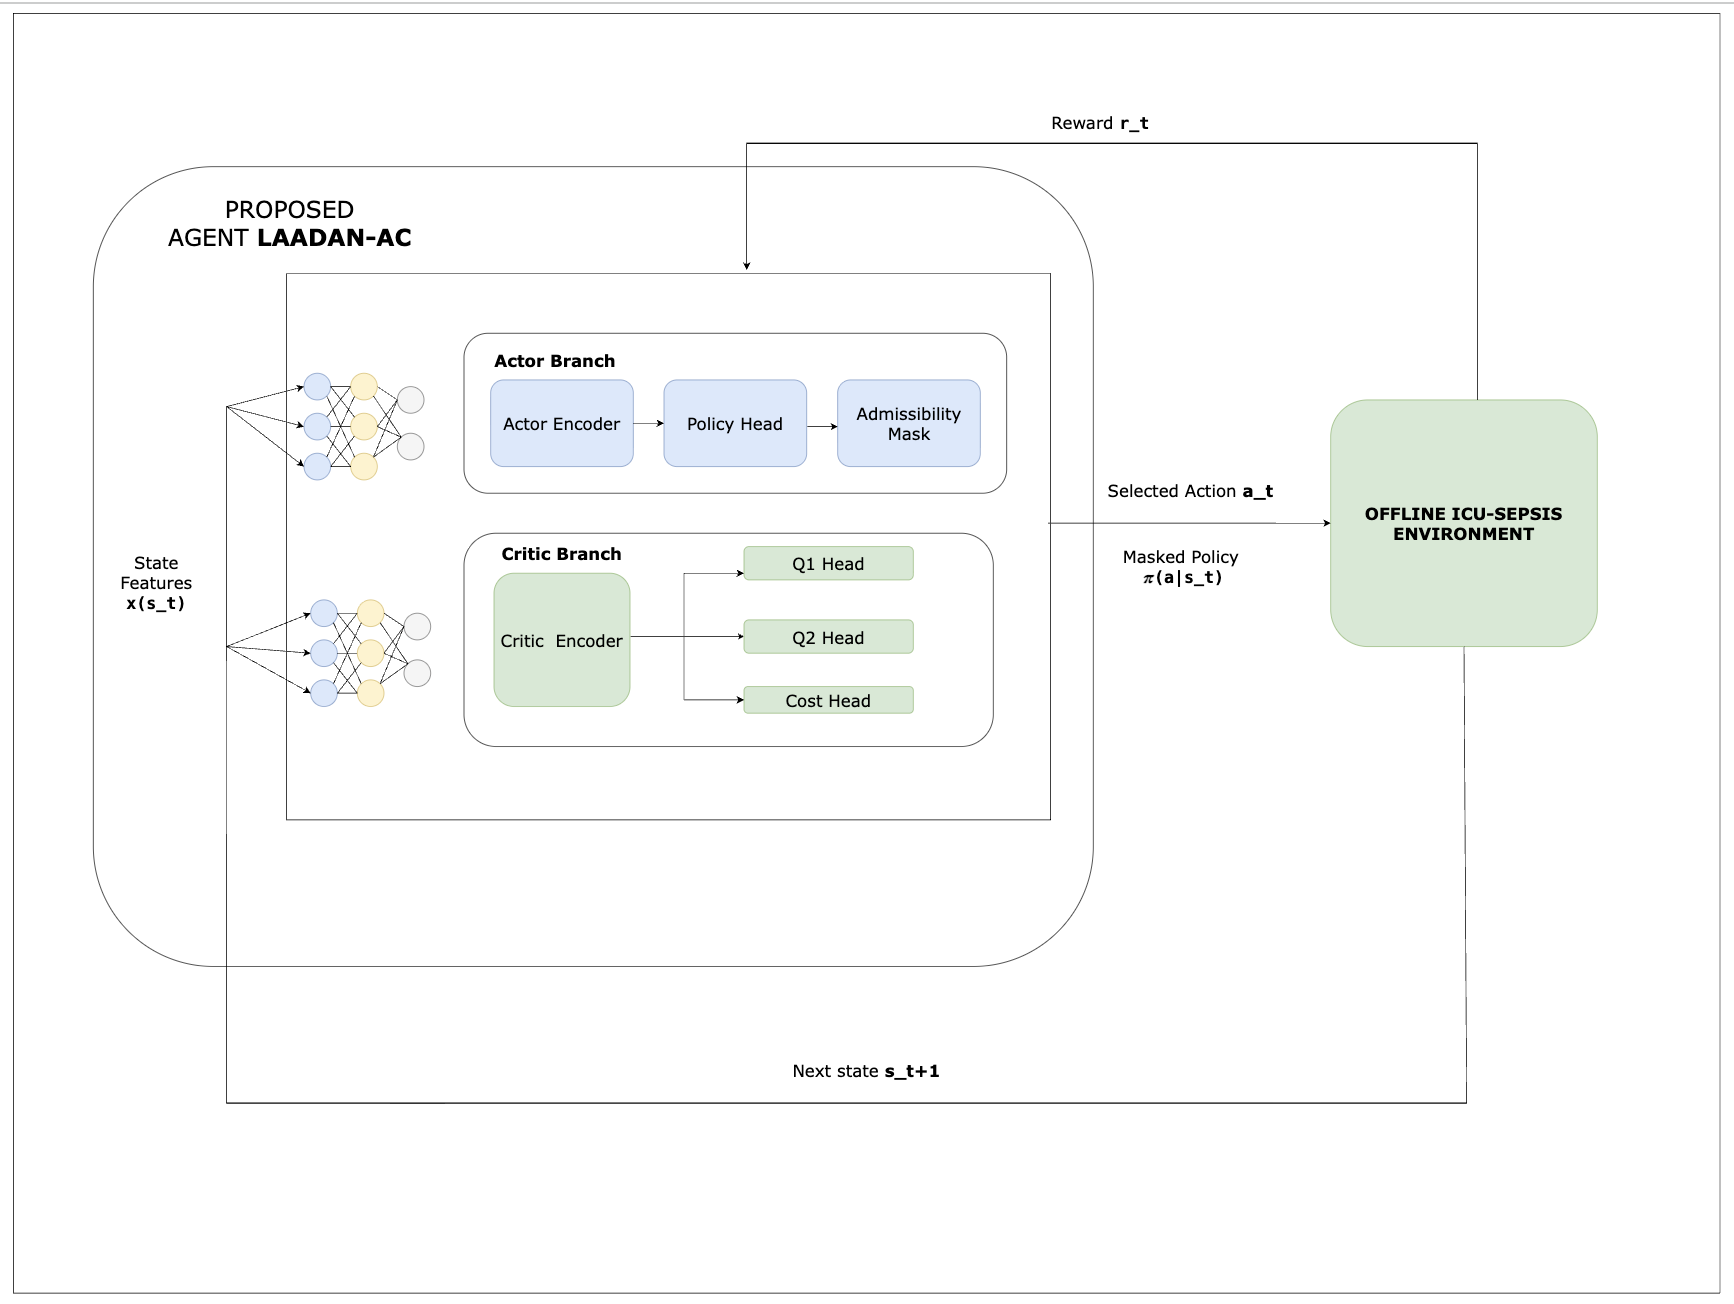

### `Explanation of the architecture`

**Figure 1** shows the proposed LAADAN-AC architecture. The input to the agent is the current patient-state representation, written as **x(sₜ)**. In this project, this state is represented using the benchmark’s released 47-dimensional standardised state-centre features.

Inside LAADAN-AC, the input is processed by two deep neural network branches:

- the **actor branch**
- the **critic branch**

The **actor branch** learns the treatment policy. It contains an **actor encoder** followed by a **policy head**. The policy head produces action preferences for the 25 treatment actions. These action scores are then filtered by the **admissibility mask**, which removes actions that are not sufficiently supported by the dataset. This produces the masked policy **π(a | sₜ)**. From this masked policy, the selected action **aₜ** is sent to the ICU-Sepsis benchmark environment.

The **critic branch** learns how good or costly actions are. It contains a **critic encoder** and three heads:
- **Q1 head**
- **Q2 head**
- **Cost head**

The two Q-heads estimate expected return values and are used in a double-critic style to improve stability and reduce overestimation. The **cost head** estimates safety-related cost, which is used by the Lagrangian part of the method to discourage inadmissible behaviour.

The **offline ICU-Sepsis environment** represents the released benchmark MDP. It receives the selected action **aₜ**, then returns a reward **rₜ** and the **next state sₜ₊₁**. This closes the reinforcement-learning loop.

So overall, the actor chooses actions, while the critic evaluates them. The actor is guided not only by reward, but also by:
- the admissibility mask,
- conservative critic regularisation,
- expert-policy regularisation,
- smoothness regularisation,
- and the Lagrangian cost term.

This design is intended to produce a policy that keeps strong survival performance while remaining safe and close to supported expert behaviour. The architecture diagram was created using diagrams.net to visually summarise the LAADAN-AC agent, the ICU-Sepsis benchmark environment, and the actor-critic reinforcement-learning loop (JGraph Ltd., 2026). 

In [ ]:
%%writefile models.py

# AUTHOR: RIYA BASAK



# models.py

# Neural network definitions for the ICU-Sepsis offline learning project.

# Purpose of this file:
# 1. Define the small neural-network building blocks used by all agents.
# 2. Keep the model code readable and closely aligned with the experiment logic.
# 3. Support four agent families used in the coursework:
#    - Behavior Cloning (BC)
#    - Conservative Q-Learning (CQL)
#    - Vanilla Offline Actor-Critic (VOAC)
#    - Lagrangian Admissibility-Aware Deep Action-Nudging Actor-Critic (LAADAN-AC)

# Libraries I used in this file

# Importing the main PyTorch package.
import torch

# Importing PyTorch neural-network layers and module base class.
import torch.nn as nn


class MLPEncoder(nn.Module):
    
    """
    Small feed-forward encoder for the released ICU-Sepsis state features.

    The ICU-Sepsis benchmark provides one feature vector per discrete state.
    This encoder transforms that input vector into a learned latent
    representation, which is then consumed by policy or value heads.

   This class exists because:
    - It avoids repeating the same encoder definition in several models.
    - It keeps the code modular and easier to maintain.
    - It makes the architectures more consistent across baselines and the
      proposed model.
    """

    def __init__(self, input_dim, hidden_dim=128, latent_dim=128, dropout=0.10):
        
        """
        Building the MLP encoder.

        Parameters
        ----------
        input_dim : int
            Number of input features per state.
        hidden_dim : int, default=128
            Width of the hidden layer.
        latent_dim : int, default=128
            Size of the output latent representation.
        dropout : float, default=0.10
            Dropout probability used as regularisation during training.
        """

        # Initialising the parent nn.Module class.
        
        super().__init__()

        # Building the encoder as a simple sequential stack:
        # Linear -> ReLU -> Dropout -> Linear -> ReLU
        #
        # This is intentionally small because the benchmark state space is not an
        # image or sequence task requiring deep or convolutional architectures.
        self.net = nn.Sequential(
            # First linear layer maps raw state features to hidden features.
            nn.Linear(input_dim, hidden_dim),

            # ReLU adds non-linearity so the encoder can learn non-linear mappings.
            nn.ReLU(),

            # Dropout acts only during training and helps reduce overfitting.
            nn.Dropout(dropout),

            # Second linear layer maps hidden features to the latent space.
            nn.Linear(hidden_dim, latent_dim),

            # Final ReLU keeps the latent representation non-linear.
            nn.ReLU(),
        )

    def forward(self, x):
        
        """
        Running a forward pass through the encoder.

        Parameters

        x : torch.Tensor
            Input state features of shape [batch_size, input_dim] or [num_states, input_dim].

        Returns

        torch.Tensor
            Encoded latent representation.
        """

        # Passing the input through the sequential MLP defined above.
        return self.net(x)


class PolicyHead(nn.Module):
    
    """
    Policy output head.

    This head maps a latent representation to one logit per discrete action.
    The head itself does not apply softmax. That is done later in training or
    evaluation depending on whether the code wants:
    - logits
    - a soft policy
    - a masked soft policy
    - a greedy one-hot policy
    """

    def __init__(self, latent_dim, num_actions):
        
        """
        Building the policy head.

        Parameters

        latent_dim : int
            Size of the incoming latent representation.
        num_actions : int
            Number of discrete actions in the benchmark.
        """

        # Initialising parent class.
        super().__init__()

        # Single linear layer projecting latent features to action logits.
        self.linear = nn.Linear(latent_dim, num_actions)

    def forward(self, z):
        
        """
        Map latent vector(s) to action logits.

        Parameters
    
        z : torch.Tensor
            Latent representation.

        Returns
      
        torch.Tensor
            One raw score (logit) per action.
        """

        # Applying the linear projection.
        return self.linear(z)


class QHead(nn.Module):
    
    """
    Q-value / score output head.

    This head maps a latent representation to one scalar score per discrete
    action. In CQL and actor-critic methods, these scores represent learned
    action values or value-like estimates.
    """

    def __init__(self, latent_dim, num_actions):
        
        """
        Building the Q head.

        Parameters
        ----------
        latent_dim : int
            Size of the incoming latent representation.
        num_actions : int
            Number of discrete actions in the benchmark.
        """

        # Initialising parent class.
        super().__init__()

        # Single linear layer projecting latent features to one value per action.
        self.linear = nn.Linear(latent_dim, num_actions)

    def forward(self, z):
        
        """
        Mapping latent vector(s) to action-value scores.

        Parameters
  
        z : torch.Tensor
            Latent representation.

        Returns
       
        torch.Tensor
            One score per action.
        """

        # Applying the linear projection.
        return self.linear(z)


class BehaviorCloningNet(nn.Module):
    
    """
    Behaviour Cloning baseline.

    This model is the simplest policy-learning baseline in the project.
    It only tries to imitate the released expert policy.

    Architectural structure:
    state features -> encoder -> policy head -> logits

    It does not learn:
    - Q-values
    - critics
    - cost estimates
    """

    def __init__(self, input_dim, num_actions, hidden_dim=128, latent_dim=128, dropout=0.10):
        
        """
        Building the Behaviour Cloning network.

        Parameters

        input_dim : int
            Number of input state features.
        num_actions : int
            Number of discrete actions.
        hidden_dim : int, default=128
            Encoder hidden size.
        latent_dim : int, default=128
            Encoder output size.
        dropout : float, default=0.10
            Dropout probability in the encoder.
        """

        # Initialising parent class.
        super().__init__()

        # Building the feature encoder for the state representation.
        self.encoder = MLPEncoder(
            input_dim,
            hidden_dim=hidden_dim,
            latent_dim=latent_dim,
            dropout=dropout,
        )

        # Building the policy head that converts latent features to action logits.
        self.policy_head = PolicyHead(latent_dim, num_actions)

    def forward(self, x):
        
        """
        Forward pass for Behaviour Cloning.

        Parameters
    
        x : torch.Tensor
            Input state features.

        Returns
 
        torch.Tensor
            Policy logits over actions.
        """

        # Encoding the raw state features into a latent representation.
        z = self.encoder(x)

        # Mapping latent representation to action logits.
        return self.policy_head(z)


class ConservativeQNet(nn.Module):
    
    """
    Conservative fitted-Q baseline.

    This model is used by the CQL baseline.
    It learns one Q-value for each discrete action and later training code
    applies a conservative offline-RL regulariser to these Q-values.

    Architectural structure:
    state features -> encoder -> Q head -> Q-values
    """

    def __init__(self, input_dim, num_actions, hidden_dim=128, latent_dim=128, dropout=0.10):
        
        """
        Building the Conservative Q network.

        Parameters
    
        input_dim : int
            Number of input state features.
        num_actions : int
            Number of discrete actions.
        hidden_dim : int, default=128
            Encoder hidden size.
        latent_dim : int, default=128
            Encoder output size.
        dropout : float, default=0.10
            Dropout probability in the encoder.
        """

        # Initialising parent class.
        super().__init__()

        # Building the state encoder.
        self.encoder = MLPEncoder(
            input_dim,
            hidden_dim=hidden_dim,
            latent_dim=latent_dim,
            dropout=dropout,
        )

        # Building the Q-value head that outputs one score per action.
        self.q_head = QHead(latent_dim, num_actions)

    def forward(self, x):
        
        """
        Forward pass for the Conservative Q network.

        Parameters
   
        x : torch.Tensor
            Input state features.

        Returns
     
        torch.Tensor
            Q-values for all actions.
        """

        # Encoding state features into latent space.
        z = self.encoder(x)

        # Mapping latent features to Q-values.
        return self.q_head(z)


class OfflineActorCriticNet(nn.Module):
    
    """
    Generic offline actor-critic backbone.

    This class is shared by:
    - VOAC: the plain offline actor-critic ablation
    - LAADAN-AC: the proposed admissibility-aware actor-critic

    Important design choice:
    The actor and critic use separate encoders rather than a single shared one.

    Why this is a good design choice for my project:
    - The actor is trying to learn a good policy.
    - The critics are trying to estimate value-like quantities.
    - These objectives can pull shared features in different directions.
    - Separate encoders reduce that interference and make the architecture
      easier to reason about.

    Output components:
    - actor logits
    - first Q head
    - second Q head
    - optional cost head
    """

    def __init__(
        self,
        input_dim,
        num_actions,
        hidden_dim=128,
        latent_dim=128,
        dropout=0.10,
        use_cost_head=False,
    ):
        """
        Building the actor-critic backbone.

        Parameters

        input_dim : int
            Number of input state features.
        num_actions : int
            Number of discrete actions.
        hidden_dim : int, default=128
            Encoder hidden size.
        latent_dim : int, default=128
            Encoder output size.
        dropout : float, default=0.10
            Dropout probability in the encoders.
        use_cost_head : bool, default=False
            If True, include an extra cost head.
            This is used by LAADAN-AC but not by VOAC.
        """

        # Initialising parent class.
        super().__init__()


        # Actor branch

        # Separating encoder for policy learning.
        self.actor_encoder = MLPEncoder(
            input_dim,
            hidden_dim=hidden_dim,
            latent_dim=latent_dim,
            dropout=dropout,
        )


        # Critic branch

        # Separating encoder for value learning.
        self.critic_encoder = MLPEncoder(
            input_dim,
            hidden_dim=hidden_dim,
            latent_dim=latent_dim,
            dropout=dropout,
        )

        # Policy head produces one logit per action from actor latent features.
        self.actor_head = PolicyHead(latent_dim, num_actions)

        # First reward/value critic head.
        self.q1_head = QHead(latent_dim, num_actions)

        # Second reward/value critic head.
        # Using two critics is common in actor-critic methods because it can
        # reduce over-optimistic value estimates.
        self.q2_head = QHead(latent_dim, num_actions)

        # Recording whether this network should include a cost head.
        self.use_cost_head = bool(use_cost_head)

        # If requested, create the cost head; otherwise store None.
        #
        # LAADAN-AC uses this cost head to model inadmissibility-related cost.
        # VOAC does not use it.
        self.cost_head = QHead(latent_dim, num_actions) if self.use_cost_head else None

    def actor_logits(self, x):
        
        """
        Computing policy logits from the actor branch only.

        Parameters
       
        x : torch.Tensor
            Input state features.

        Returns
   
        torch.Tensor
            Action logits from the actor.
        """

        # Encoding state features using the actor-specific encoder.
        actor_latent = self.actor_encoder(x)

        # Converting actor latent features into action logits.
        return self.actor_head(actor_latent)

    def critic_values(self, x):
        
        """
        Computing critic outputs from the critic branch only.

        Parameters
        
        x : torch.Tensor
            Input state features.

        Returns
        
        tuple
            (q1, q2, cost)
            where cost is None if no cost head exists.
        """

        # Encoding state features using the critic-specific encoder.
        critic_latent = self.critic_encoder(x)

        # First critic estimates one score per action.
        q1 = self.q1_head(critic_latent)

        # Second critic estimates one score per action.
        q2 = self.q2_head(critic_latent)

        # If cost head exists, compute cost scores too; otherwise return None.
        cost = self.cost_head(critic_latent) if self.cost_head is not None else None

        return q1, q2, cost

    def forward(self, x):
        
        """
        Full forward pass for the actor-critic model.

        Parameters
      
        x : torch.Tensor
            Input state features.

        Returns
  
        dict
            Dictionary containing:
            - "logits": actor policy logits
            - "q1": first critic output
            - "q2": second critic output
            - "cost": optional cost output or None
        """

        # Getting actor logits from actor branch.
        logits = self.actor_logits(x)

        # Getting critic outputs from critic branch.
        q1, q2, cost = self.critic_values(x)

        # Returning all outputs together so training code can access whichever
        # parts it needs.
        return {
            "logits": logits,
            "q1": q1,
            "q2": q2,
            "cost": cost,
        }


@torch.no_grad()
def soft_update(target_module, source_module, tau):
    
    """
    Standard target-network soft update.

    This function updates the parameters of a target network so that they move
    gradually toward the parameters of a source network.

    Update rule:
        target = tau * source + (1 - tau) * target

    Interpretation of tau:
    - tau close to 0  -> slow tracking, smoother but less responsive
    - tau close to 1  -> fast tracking, more responsive but less stable

    The @torch.no_grad() decorator is used because this is a parameter-copying
    operation, not something that should create gradients for backpropagation.
    """

    # Looping through target and source parameters in matching order.
    for target_param, source_param in zip(target_module.parameters(), source_module.parameters()):
        # Replacing target parameter data with the soft-updated combination.
        target_param.data.copy_(tau * source_param.data + (1.0 - tau) * target_param.data)

Overwriting models.py


# `Training and evaluation setup`

This project compared four offline reinforcement-learning methods on the ICU-Sepsis benchmark: Behaviour Cloning (BC), Conservative Q-Learning (CQL), Vanilla Offline Actor-Critic (VOAC), and the proposed Lagrangian Admissibility-Aware Deep Action-Nudging Actor-Critic (LAADAN-AC). The benchmark used 716 states, 25 actions, 47 standardised state-centre features, horizon 50, and terminal rewards where survival = 1 and death = 0. Since γ = 1, average return and survival rate are numerically the same in this experiment.

The setup was kept fair: all models used the same benchmark, state representation, horizon, random seeds, hidden dimension, latent dimension, dropout value, and exact finite-horizon evaluator. Five seeds (42–46) were used, and the main results are reported as mean ± 95% confidence interval. A separate held-out validation split was not used because this was a fixed benchmark MDP study. Instead, each model was evaluated every 10 epochs on the released MDP, and the best saved checkpoint was selected by survival rate, with inadmissibility reported separately as the main safety metric.

The main experiment used `use_one_hot_states=False` because the 47-dimensional state-centre features contain information about state similarity. A separate one-hot sensitivity check showed the same main pattern: VOAC kept the highest raw survival but high inadmissibility, while LAADAN-AC kept zero inadmissibility. This supports the conclusion that LAADAN-AC’s safety came mainly from its design, not only from the state representation.

# `Algorithm 1. LAADAN-AC training procedure`

**Input:**  
Fixed ICU-Sepsis benchmark MDP with transition table **P**, reward table **R**, immediate-cost table, smoothness-cost table, state features **X**, expert-safe policy **πE**, admissible-action mask **M**, actor network, critic networks, target networks, Lagrange multiplier **λ = 0**, discount factor **γ**, target update rate **τ**, conservative weight **α**, expert-KL weight **η**, smoothness weight **μ**, entropy coefficient **β**, cost budget **d**, Lagrange learning rate **ρ**, number of epochs **E**, and evaluation interval **K**.

```text
for epoch = 1, 2, ..., E do

    1. Use the target actor to build a masked target policy:
           πtarget(a|s) = masked_softmax(actor_target(X), M)

    2. Estimate target reward values using the smaller of the two target critics:
           min_Qtarget = min(Q1_target, Q2_target)

    3. Build the Bellman reward target.

    4. Build the Bellman cost target.

    5. Update the two reward critics by minimising Bellman error.

    6. Update the cost critic by minimising cost Bellman error.

    7. Add conservative critic regularisation to reduce over-valuing weakly supported actions.

    8. Use the current actor to build the current masked policy:
           π(a|s) = masked_softmax(actor(X), M)

    9. Compute the actor loss using:
           reward maximisation,
           admissibility awareness,
           cost penalty,
           expert-policy regularisation,
           smoothness regularisation,
           and entropy regularisation.

    10. Update the actor parameters.

    11. Update the Lagrange multiplier:
           λ ← max(0, λ + ρ(mean_expected_cost - d))

    12. Soft-update the target networks.

    13. Every K epochs:
           build the masked greedy policy,
           evaluate it using exact finite-horizon policy evaluation,
           and save the checkpoint if survival improves.

end for


In [ ]:
%%writefile trainers.py

# AUTHOR: RIYA BASAK



# trainers.py

# Training loops for the four-model offline ICU-Sepsis experiment.
#
# Models trained in this file:
# 1. Behaviour Cloning (BC)
# 2. Conservative Q-Learning (CQL)
# 3. Vanilla Offline Actor-Critic (VOAC)
# 4. Lagrangian Admissibility-Aware Deep Action-Nudging Actor-Critic (LAADAN-AC) 
#
#  Purpose of this file:
# - It contains the full optimisation logic for all four agents.
# - It defines how training, evaluation, checkpointing, and result aggregation
#   are done.
# - It is therefore the main learning pipeline file of the project.
#

# Libraries I used in this file

# CSV is used for writing training histories to disk.
import csv

# for saving metrics in a structured reproducible format.
import json

# for filesystem paths and folder creation.
import os

# to measure total training time for each run.
import time

# for metric aggregation and summary statistics.
import numpy as np

# PyTorch is used for all tensor operations, neural-network training,
# optimisation, gradient updates, and checkpointing.
import torch

# Importing all network classes and the target-network update helper
# from models.py.
from models import BehaviorCloningNet, ConservativeQNet, OfflineActorCriticNet, soft_update


def ensure_dir(path):
    
    """
    Creating a folder if it does not already exist.

    This helper is used before saving checkpoints, histories, and metrics.
    """
    # Checking whether the target folder already exists.
    if not os.path.exists(path):
        # If not, create it.
        os.makedirs(path)


# Precomputed critical t-values for a 95% confidence interval.
#
# Why use these?
# With only a small number of seeds, using a t-based interval is more appropriate
# than pretending the normal approximation is always exact.
_T_CRIT_95 = {
    2: 12.706,
    3: 4.303,
    4: 3.182,
    5: 2.776,
    6: 2.571,
    7: 2.447,
    8: 2.365,
    9: 2.306,
    10: 2.262,
}


def mean_ci95(values):
    
    """
    Returning mean, sample standard deviation, and 95% t-based confidence interval.

    This is used for multi-seed reporting, which is important for fair and
    reproducible comparison in the coursework.

    Parameters
  
    values : array-like
        List or array of metric values across different seeds.

    Returns

    dict
        Dictionary containing:
        - n
        - mean
        - std
        - ci95_half
        - ci95_low
        - ci95_high
    """
    # Converting the input to a NumPy array of floats.
    values = np.asarray(values, dtype=float)

    # Removing NaN or infinite values before computing statistics.
    values = values[np.isfinite(values)]

    # Counting the number of valid observations.
    n = int(values.size)

    # If there are no valid values, return NaNs so downstream code can detect
    # the missing summary cleanly.
    if n == 0:
        return {
            "n": 0,
            "mean": np.nan,
            "std": np.nan,
            "ci95_half": np.nan,
            "ci95_low": np.nan,
            "ci95_high": np.nan,
        }

    # Computing the arithmetic mean.
    mean = float(np.mean(values))

    # If only one value exists, the spread and CI are effectively zero because
    # there is no multi-run variation to estimate.
    if n == 1:
        return {
            "n": 1,
            "mean": mean,
            "std": 0.0,
            "ci95_half": 0.0,
            "ci95_low": mean,
            "ci95_high": mean,
        }

    # Computing sample standard deviation with ddof=1 for an unbiased
    # sample-based estimate.
    std = float(np.std(values, ddof=1))

    # Look up the t critical value; if n is outside the small dictionary, use
    # 1.96 as a reasonable large-sample approximation.
    t_crit = _T_CRIT_95.get(n, 1.96)

    # Computing the half-width of the 95% confidence interval.
    ci95_half = float(t_crit * std / np.sqrt(n))

    # Returning the full summary dictionary.
    return {
        "n": n,
        "mean": mean,
        "std": std,
        "ci95_half": ci95_half,
        "ci95_low": mean - ci95_half,
        "ci95_high": mean + ci95_half,
    }


def plain_softmax_from_logits(logits):
    
    """
    Standard softmax with no admissibility masking.

    Used when the policy is allowed to place probability mass over all actions.
    """
    # Converting raw action logits to probabilities over actions.
    return torch.softmax(logits, dim=1)


def plain_log_softmax_from_logits(logits):
    
    """
    Standard log-softmax with no admissibility masking.

    This is numerically stable and useful for entropy and KL computations.
    """
    # Converting raw logits to log-probabilities.
    return torch.log_softmax(logits, dim=1)


def masked_softmax_from_logits(logits, admissible_mask):
    
    """
    Softmax after hiding inadmissible actions with a large negative logit.

    Why this works:
    actions with -1e9 logits receive effectively zero probability after softmax.
    """
    # Creating a tensor with a very large negative value matching the logits shape.
    large_negative = torch.full_like(logits, -1e9)

    # Keeping original logits where actions are admissible; replace inadmissible
    # actions with the large negative value.
    masked = torch.where(admissible_mask > 0.5, logits, large_negative)

    # Converting the masked logits into a valid probability distribution.
    return torch.softmax(masked, dim=1)


def masked_log_softmax_from_logits(logits, admissible_mask):
    
    """
    Log-softmax after hiding inadmissible actions with a large negative logit.

    This is the masked counterpart of plain_log_softmax_from_logits().
    """
    # Creating the same large negative tensor used to suppress forbidden actions.
    large_negative = torch.full_like(logits, -1e9)

    # Replacing inadmissible-action logits with a very negative number.
    masked = torch.where(admissible_mask > 0.5, logits, large_negative)

    # Returning log-probabilities after masking.
    return torch.log_softmax(masked, dim=1)


def greedy_policy_from_logits(logits):
    
    """
    Deterministic one-hot policy from raw logits.

    This chooses the single highest-logit action in each state.
    """
    # Finding the index of the largest logit in each row.
    best = torch.argmax(logits, dim=1)

    # Creating a zero matrix with the same shape as the logits.
    policy = torch.zeros_like(logits)

    # Writing a 1.0 into the best-action column for each row.
    policy.scatter_(1, best.unsqueeze(1), 1.0)

    # Returning the resulting one-hot deterministic policy.
    return policy


def masked_greedy_policy_from_logits(logits, admissible_mask):
    
    """
    Deterministic one-hot policy from logits after admissibility masking.

    This ensures the greedy action is selected only from admissible actions.
    """
    # Building the large negative filler used to suppress forbidden actions.
    large_negative = torch.full_like(logits, -1e9)

    # Replacing inadmissible logits with the large negative constant.
    masked = torch.where(admissible_mask > 0.5, logits, large_negative)

    # Choosing the best admissible action in each state.
    best = torch.argmax(masked, dim=1)

    # Creating an all-zero policy tensor.
    policy = torch.zeros_like(logits)

    # Placing 1.0 on the chosen action index for each row.
    policy.scatter_(1, best.unsqueeze(1), 1.0)

    # Returning the masked greedy policy.
    return policy


def weighted_policy_kl(logits, target_policy, admissible_mask=None):
    
    """
    KL(target || model).

    If admissible_mask is supplied, logits are masked first.

    This is mainly used for imitation-style learning or expert-regularisation.
    """
    # Choosing either masked or unmasked log-probabilities depending on whether
    # the action space should be restricted.
    if admissible_mask is None:
        log_probs = plain_log_softmax_from_logits(logits)
    else:
        log_probs = masked_log_softmax_from_logits(logits, admissible_mask)

    # Normalizing the target policy to ensure each row sums to 1 even if the input
    # arrives with minor numerical mismatch.
    target = target_policy / torch.clamp(torch.sum(target_policy, dim=1, keepdim=True), min=1e-8)

    # Computing KL(target || model) row-wise:
    # sum target * (log target - log model)
    kl = torch.sum(target * (torch.log(target + 1e-8) - log_probs), dim=1)

    # Returning the mean KL over all states.
    return torch.mean(kl)


def cql_regularizer(q_values, expert_policy, admissible_mask=None):
    
    """
    Conservative Q-Learning style penalty.

    If admissible_mask is supplied, the conservative log-sum-exp is applied only
    to admissible actions.

    Intuition:
    - logsumexp encourages caution against assigning too much value to many actions
    - the data_term anchors values toward expert-supported actions
    """
    # If no mask is provided, applying logsumexp over all actions.
    if admissible_mask is None:
        conservative_term = torch.logsumexp(q_values, dim=1)
    else:
        # Otherwise hide inadmissible actions before logsumexp.
        masked = torch.where(admissible_mask > 0.5, q_values, torch.full_like(q_values, -1e9))
        conservative_term = torch.logsumexp(masked, dim=1)

    # Computing the value of expert-supported actions under the current Q-values.
    data_term = torch.sum(expert_policy * q_values, dim=1)

    # Returning the mean conservative penalty.
    return torch.mean(conservative_term - data_term)


def masked_action_mse(pred, target, action_mask=None):
    
    """
    Mean squared error over all actions or over a masked subset.

    This is useful for LAADAN because the actor only uses admissible actions,
    so critic fitting can be focused on that same effective action space.
    """
    # Computing elementwise squared error.
    squared = (pred - target) ** 2

    # If no mask is supplied, just return the ordinary mean squared error.
    if action_mask is None:
        return torch.mean(squared)

    # Converting the mask to float so it can be used as weights.
    weights = action_mask.float()

    # Computing the sum of weights; clamp to at least 1.0 so division is safe.
    denom = torch.clamp(torch.sum(weights), min=1.0)

    # Returning the weighted masked MSE.
    return torch.sum(squared * weights) / denom


def save_history_csv(path, rows):
    
    """
    Writing a list of dictionaries to CSV, allowing rows to have different keys.

    This is helpful because some metrics appear only at evaluation epochs,
    while others appear every epoch.
    """
    # If there is no history to save, do nothing.
    if not rows:
        return

    # Collecting the full union of field names across all rows.
    fieldnames = []
    seen = set()
    for row in rows:
        for key in row.keys():
            if key not in seen:
                seen.add(key)
                fieldnames.append(key)

    # Opening the destination CSV file.
    with open(path, "w", newline="", encoding="utf-8") as handle:
        # Building the CSV writer using the discovered fieldnames.
        writer = csv.DictWriter(handle, fieldnames=fieldnames, extrasaction="ignore")

        # Writing the header row first.
        writer.writeheader()

        # Writing each history row, filling missing keys with empty strings.
        for row in rows:
            full_row = {key: row.get(key, "") for key in fieldnames}
            writer.writerow(full_row)


def summarize_history(history):
    
    """
    Creating a compact summary from a history whose rows may have different keys.

    For each numeric field, store:
    - last value
    - best minimum
    - best maximum
    """
    # If no history exists, return an empty summary.
    if not history:
        return {}

    # Building a list of all unique keys seen across rows.
    all_keys = []
    seen = set()
    for row in history:
        for key in row.keys():
            if key not in seen:
                seen.add(key)
                all_keys.append(key)

    # Preparing the output dictionary.
    summary = {}

    # Processing each field independently.
    for key in all_keys:
        values = []

        # Collecting all finite numeric values for the current key.
        for row in history:
            value = row.get(key, np.nan)
            if isinstance(value, (int, float, np.integer, np.floating)) and np.isfinite(value):
                values.append(float(value))

        # If at least one valid value exists, store last, min, and max summaries.
        if values:
            summary[key + "_last"] = values[-1]
            summary[key + "_best_min"] = float(np.min(values))
            summary[key + "_best_max"] = float(np.max(values))

    # Returning the compact history summary.
    return summary


def epoch_to_fraction_of_best(history, metric_name, fraction=0.95):
    
    """
    Finding the first epoch that reaches a fraction of the best value.

    This gives a simple convergence summary for the report, such as:
    "How many epochs were needed before the run reached 95% of its best survival?"
    """
    # Collecting all finite (epoch, value) pairs for the requested metric.
    metric_pairs = []
    for row in history:
        value = row.get(metric_name, np.nan)
        if np.isfinite(value):
            metric_pairs.append((int(row["epoch"]), float(value)))

    # If no valid metric values exist, convergence cannot be estimated.
    if not metric_pairs:
        return None

    # Finding the best metric value achieved during training.
    best_value = max(value for _, value in metric_pairs)

    # Setting the convergence threshold as the chosen fraction of the best value.
    threshold = fraction * best_value

    # Returning the first epoch that reaches or exceeds that threshold.
    for epoch, value in metric_pairs:
        if value >= threshold:
            return int(epoch)

    # If never reached, return None.
    return None


def save_model_run(seed_dir, model, history, metrics):
    
    """
    Saving the trained model, CSV history, and metrics JSON for one seed.

    This is important for reproducibility and later testing.
    """
    # Making sure the output folder exists.
    ensure_dir(seed_dir)

    # Saving the model weights.
    torch.save(model.state_dict(), os.path.join(seed_dir, "model.pt"))

    # Saving the training history as CSV.
    save_history_csv(os.path.join(seed_dir, "history.csv"), history)

    # Saving the metric dictionary as JSON.
    with open(os.path.join(seed_dir, "metrics.json"), "w", encoding="utf-8") as handle:
        json.dump(metrics, handle, indent=2)


@torch.no_grad()
def evaluate_policy_set(benchmark, policy, soft_policy=None):
    
    """
    Evaluating the primary policy and optionally a secondary soft policy.

    The primary policy is the one used for:
    - model comparison
    - best-checkpoint selection
    - final reporting

    The optional soft policy is stored only for extra analysis.
    """
    # Evaluating the primary policy exactly on the benchmark.
    metrics = benchmark.exact_policy_evaluation(policy)

    # If a soft-policy version is also provided, evaluate it too and append
    # those values as auxiliary metrics.
    if soft_policy is not None:
        soft_metrics = benchmark.exact_policy_evaluation(soft_policy)
        metrics["soft_survival_rate"] = soft_metrics["survival_rate"]
        metrics["soft_inadmissibility_rate"] = soft_metrics["inadmissibility_rate"]
        metrics["soft_avg_return"] = soft_metrics["avg_return"]
        metrics["soft_policy_entropy"] = soft_metrics["policy_entropy"]
        metrics["soft_mean_kl_to_expert"] = soft_metrics["mean_kl_to_expert"]

    # Returning the combined metric dictionary.
    return metrics


@torch.no_grad()
def policy_numpy(tensor_policy):
    
    """
    Converting a PyTorch policy tensor to a NumPy array.

    This is used before exact evaluation and before storing policies in results.
    """
    return tensor_policy.detach().cpu().numpy()


def train_behavior_cloning(benchmark, seed, results_dir, config):
    
    """
    Training the clinician-imitation baseline.

    Primary evaluation uses a greedy policy for fair like-for-like comparison with
    deterministic CQL evaluation. Soft-policy metrics are also stored.
    """
    # Setting Python, NumPy, and Torch seeds for reproducibility.
    benchmark.set_seed(seed)

    # Recording the training device for convenience.
    device = benchmark.device

    # Building the Behavior Cloning network and moving it to the target device.
    model = BehaviorCloningNet(
        benchmark.feature_dim,
        benchmark.num_actions,
        hidden_dim=int(config.get("hidden_dim", 128)),
        latent_dim=int(config.get("latent_dim", 128)),
        dropout=float(config.get("dropout", 0.10)),
    ).to(device)

    # Creating the Adam optimizer for all model parameters.
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=float(config.get("lr", 1e-3)),
        weight_decay=float(config.get("weight_decay", 1e-5)),
    )

    # Reading high-level training settings from the configuration.
    epochs = int(config.get("epochs", 300))
    eval_every = int(config.get("eval_every", 10))

    # Shortcut references to benchmark tensors.
    x = benchmark.state_features_t
    target = benchmark.expert_safe_t

    # Preparing per-epoch logging structures.
    history = []
    best_survival = -1.0
    best_state = None
    best_metrics = None

    # Recording wall-clock start time.
    start_time = time.time()

    # Main epoch loop.
    for epoch in range(1, epochs + 1):
        # Putting the model in training mode so dropout is active as intended.
        model.train()

        # Clearing old gradients.
        optimizer.zero_grad()

        # Forward pass: get policy logits for every state.
        logits = model(x)

        # Computing imitation loss against the benchmark expert-safe policy.
        kl_loss = weighted_policy_kl(logits, target, admissible_mask=None)

        # Building the soft policy distribution for entropy regularisation.
        probs = plain_softmax_from_logits(logits)

        # Building log-probabilities for entropy calculation.
        log_probs = plain_log_softmax_from_logits(logits)

        # Computing average policy entropy.
        entropy = -torch.mean(torch.sum(probs * log_probs, dim=1))

        # Total loss:
        # imitation loss minus optional entropy bonus.
        loss = kl_loss - float(config.get("entropy_bonus", 0.0)) * entropy

        # Backpropagate.
        loss.backward()

        # Updating parameters.
        optimizer.step()

        # Starting the row with always-available training values.
        row = {
            "epoch": epoch,
            "loss": float(loss.item()),
            "kl_loss": float(kl_loss.item()),
            "entropy": float(entropy.item()),
        }

        # Running evaluation at the chosen interval or at the final epoch.
        if epoch % eval_every == 0 or epoch == epochs:
            # Switching to evaluation mode so dropout is disabled.
            model.eval()

            with torch.no_grad():
                # Recomputing logits for evaluation.
                logits_eval = model(x)

                # Building the greedy one-hot policy used for primary comparison.
                greedy_policy = greedy_policy_from_logits(logits_eval)

                # Also keeping the soft policy for auxiliary analysis.
                soft_policy = plain_softmax_from_logits(logits_eval)

            # Evaluating both policies through the benchmark evaluator.
            metrics = evaluate_policy_set(
                benchmark,
                policy_numpy(greedy_policy),
                soft_policy=policy_numpy(soft_policy),
            )

            # Adding evaluation metrics into the current history row.
            row.update(metrics)

            # Saving checkpoint state if this is the best survival so far.
            if metrics["survival_rate"] > best_survival:
                best_survival = metrics["survival_rate"]
                best_state = {key: value.detach().cpu() for key, value in model.state_dict().items()}
                best_metrics = metrics

        # Appending the row to the training history.
        history.append(row)

    # Restoring the best checkpoint if one was captured.
    if best_state is not None:
        model.load_state_dict(best_state)

    # Computing final policy outputs from the restored best model.
    model.eval()
    with torch.no_grad():
        logits_final = model(x)
        final_policy = greedy_policy_from_logits(logits_final)
        final_soft_policy = plain_softmax_from_logits(logits_final)

    # If for some reason no evaluation was recorded, compute metrics now.
    if best_metrics is None:
        best_metrics = evaluate_policy_set(
            benchmark,
            policy_numpy(final_policy),
            soft_policy=policy_numpy(final_soft_policy),
        )

    # Building the per-seed output folder.
    seed_dir = os.path.join(results_dir, "bc", "seed_" + str(seed))

    # Saving checkpoint, history, and metrics.
    save_model_run(seed_dir, model, history, best_metrics)

    # Returning a structured result dictionary.
    return {
        "name": "Behavior Cloning",
        "seed": seed,
        "model": model,
        "policy": policy_numpy(final_policy),
        "analysis_policy": policy_numpy(final_soft_policy),
        "history": history,
        "metrics": best_metrics,
        "train_time_seconds": float(time.time() - start_time),
        "convergence_epoch_95": epoch_to_fraction_of_best(history, "survival_rate", 0.95),
    }


def train_cql(benchmark, seed, results_dir, config):
    
    """
    Training the conservative offline value-learning baseline.

    Primary evaluation uses greedy action selection from the learned Q-values.
    """
    # Setting random seeds for reproducibility.
    benchmark.set_seed(seed)

    # Recording training device.
    device = benchmark.device

    # Building the main Q-network.
    model = ConservativeQNet(
        benchmark.feature_dim,
        benchmark.num_actions,
        hidden_dim=int(config.get("hidden_dim", 128)),
        latent_dim=int(config.get("latent_dim", 128)),
        dropout=float(config.get("dropout", 0.10)),
    ).to(device)

    # Building the target Q-network.
    target_model = ConservativeQNet(
        benchmark.feature_dim,
        benchmark.num_actions,
        hidden_dim=int(config.get("hidden_dim", 128)),
        latent_dim=int(config.get("latent_dim", 128)),
        dropout=float(config.get("dropout", 0.10)),
    ).to(device)

    # Starting target model with identical weights.
    target_model.load_state_dict(model.state_dict())

    # Keeping target model in evaluation mode for stable targets.
    target_model.eval()

    # Creating the optimizer for the main model.
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=float(config.get("lr", 1e-3)),
        weight_decay=float(config.get("weight_decay", 1e-5)),
    )

    # Reading algorithm hyperparameters.
    gamma = float(config.get("gamma", 1.0))
    cql_alpha = float(config.get("cql_alpha", 1.0))
    tau = float(config.get("tau", 0.02))
    epochs = int(config.get("epochs", 300))
    eval_every = int(config.get("eval_every", 10))

    # Shortcut references to benchmark tensors.
    x = benchmark.state_features_t
    expert = benchmark.expert_safe_t
    reward_sa = benchmark.reward_sa_t
    transition = benchmark.transition_t
    terminal = benchmark.terminal_mask_t

    # Preparing tracking variables.
    history = []
    best_survival = -1.0
    best_state = None
    best_metrics = None
    start_time = time.time()

    # Main training loop.
    for epoch in range(1, epochs + 1):
        # Enabling training mode for the main model.
        model.train()

        # Clearing previous gradients.
        optimizer.zero_grad()

        # Forward pass through the current Q-network.
        q_values = model(x)

        # Building Bellman targets using the slowly updated target network.
        with torch.no_grad():
            q_target_now = target_model(x)

            # Value of next state = max Q over actions, masked by non-terminal states.
            next_v = torch.max(q_target_now, dim=1).values * (1.0 - terminal)

            # Bellman target for every state-action pair.
            bellman_target = reward_sa + gamma * torch.einsum("san,n->sa", transition, next_v)

        # Temporal-difference loss over all state-action values.
        td_loss = torch.mean((q_values - bellman_target) ** 2)

        # Conservative penalty discouraging unsupported value inflation.
        conservative_loss = cql_regularizer(q_values, expert, admissible_mask=None)

        # Total CQL objective.
        loss = td_loss + cql_alpha * conservative_loss

        # Backpropagate.
        loss.backward()

        # Clipping gradients for stability.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        # Optimizer step.
        optimizer.step()

        # Soft-update the target network.
        soft_update(target_model, model, tau)

        # Keepping the target network in eval mode after update.
        target_model.eval()

        # Log training losses.
        row = {
            "epoch": epoch,
            "loss": float(loss.item()),
            "td_loss": float(td_loss.item()),
            "cql_loss": float(conservative_loss.item()),
        }

        # Periodic evaluation.
        if epoch % eval_every == 0 or epoch == epochs:
            # Disable dropout in the main model.
            model.eval()

            with torch.no_grad():
                # Getting current Q-values as NumPy.
                q_now = model(x).detach().cpu().numpy()

                # Converting Q-values to a deterministic greedy policy.
                greedy_policy = benchmark.greedy_policy_from_q_unmasked(q_now)

            # Evaluating the greedy policy.
            metrics = benchmark.exact_policy_evaluation(greedy_policy)

            # Merging metrics into the row.
            row.update(metrics)

            # Saving best checkpoint if survival improved.
            if metrics["survival_rate"] > best_survival:
                best_survival = metrics["survival_rate"]
                best_state = {key: value.detach().cpu() for key, value in model.state_dict().items()}
                best_metrics = metrics

        # Appending row to history.
        history.append(row)

    # Restoring best checkpoint.
    if best_state is not None:
        model.load_state_dict(best_state)

    # Final policy extraction from best restored model.
    model.eval()
    with torch.no_grad():
        q_final = model(x).detach().cpu().numpy()
        final_policy = benchmark.greedy_policy_from_q_unmasked(q_final)

    # Fallback in case best metrics were never set.
    if best_metrics is None:
        best_metrics = benchmark.exact_policy_evaluation(final_policy)

    # Output folder for this seed.
    seed_dir = os.path.join(results_dir, "cql", "seed_" + str(seed))

    # Saving run outputs.
    save_model_run(seed_dir, model, history, best_metrics)

    # Returning structured run result.
    return {
        "name": "Conservative Q-Learning",
        "seed": seed,
        "model": model,
        "policy": final_policy,
        "analysis_policy": final_policy,
        "history": history,
        "metrics": best_metrics,
        "train_time_seconds": float(time.time() - start_time),
        "convergence_epoch_95": epoch_to_fraction_of_best(history, "survival_rate", 0.95),
    }


def _actor_critic_common_setup(benchmark, config, use_cost_head):
    
    """
    Building an actor-critic model pair and return commonly used benchmark tensors.

    This helper avoids repeating the same setup logic for VOAC and LAADAN-AC.
    """
    # Reading device.
    device = benchmark.device

    # Building the main actor-critic model.
    model = OfflineActorCriticNet(
        benchmark.feature_dim,
        benchmark.num_actions,
        hidden_dim=int(config.get("hidden_dim", 128)),
        latent_dim=int(config.get("latent_dim", 128)),
        dropout=float(config.get("dropout", 0.10)),
        use_cost_head=use_cost_head,
    ).to(device)

    # Building the target actor-critic model.
    target_model = OfflineActorCriticNet(
        benchmark.feature_dim,
        benchmark.num_actions,
        hidden_dim=int(config.get("hidden_dim", 128)),
        latent_dim=int(config.get("latent_dim", 128)),
        dropout=float(config.get("dropout", 0.10)),
        use_cost_head=use_cost_head,
    ).to(device)

    # Copying weights from main to target.
    target_model.load_state_dict(model.state_dict())

    # Keeping target network in eval mode.
    target_model.eval()

    # Bundle frequently used tensors for convenience.
    tensors = {
        "x": benchmark.state_features_t,
        "admissible": benchmark.admissible_mask_t,
        "expert": benchmark.expert_safe_t,
        "reward_sa": benchmark.reward_sa_t,
        "transition": benchmark.transition_t,
        "terminal": benchmark.terminal_mask_t,
        "immediate_cost": benchmark.immediate_cost_t,
        "smoothness_cost": benchmark.smoothness_cost_t,
    }

    # Returning the built models and tensor bundle.
    return model, target_model, tensors


def train_voac(benchmark, seed, results_dir, config):
    
    """
    Training the plain offline actor-critic ablation.

    Primary evaluation uses greedy action selection from actor logits so that the
    comparison is like-for-like with CQL and LAADAN primary testing.
    """
    # Setting random seeds.
    benchmark.set_seed(seed)

    # Building model, target model, and tensor bundle.
    model, target_model, tensors = _actor_critic_common_setup(benchmark, config, use_cost_head=False)

    # Actor parameters are only the actor encoder and actor head.
    actor_params = list(model.actor_encoder.parameters()) + list(model.actor_head.parameters())

    # Critic parameters are the critic encoder and the two Q heads.
    critic_params = (
        list(model.critic_encoder.parameters())
        + list(model.q1_head.parameters())
        + list(model.q2_head.parameters())
    )

    # Separating optimizer for the actor.
    actor_optimizer = torch.optim.Adam(
        actor_params,
        lr=float(config.get("actor_lr", 1e-3)),
        weight_decay=float(config.get("weight_decay", 1e-5)),
    )

    # Separating optimizer for the critics.
    critic_optimizer = torch.optim.Adam(
        critic_params,
        lr=float(config.get("critic_lr", 1e-3)),
        weight_decay=float(config.get("weight_decay", 1e-5)),
    )

    # Reading algorithm settings.
    gamma = float(config.get("gamma", 1.0))
    tau = float(config.get("tau", 0.02))
    entropy_coef = float(config.get("entropy_coef", 0.02))
    epochs = int(config.get("epochs", 300))
    eval_every = int(config.get("eval_every", 10))

    # Shortcuts to benchmark tensors.
    x = tensors["x"]
    reward_sa = tensors["reward_sa"]
    transition = tensors["transition"]
    terminal = tensors["terminal"]

    # Preparing tracking structures.
    history = []
    best_survival = -1.0
    best_state = None
    best_metrics = None
    start_time = time.time()

    # Main epoch loop.
    for epoch in range(1, epochs + 1):
        # Setting main model to training mode.
        model.train()

       
        # Critic update

        with torch.no_grad():
            # Getting target-network outputs.
            target_outputs = target_model(x)

            # Building the target policy distribution from target actor logits.
            next_probs = plain_softmax_from_logits(target_outputs["logits"])
            next_log_probs = plain_log_softmax_from_logits(target_outputs["logits"])

            # Reading both target critics.
            q1_next = target_outputs["q1"]
            q2_next = target_outputs["q2"]

            # Using the minimum of the two critics for a more conservative target.
            min_q_next = torch.min(q1_next, q2_next)

            # Computing soft value target for next state.
            next_v = torch.sum(
                next_probs * (min_q_next - entropy_coef * next_log_probs),
                dim=1,
            ) * (1.0 - terminal)

            # Bellman target for every state-action pair.
            q_target = reward_sa + gamma * torch.einsum("san,n->sa", transition, next_v)

        # Resetting critic gradients.
        critic_optimizer.zero_grad()

        # Forward pass through current model.
        outputs = model(x)
        q1 = outputs["q1"]
        q2 = outputs["q2"]

        # Computing critic losses against the shared target.
        q1_loss = torch.mean((q1 - q_target) ** 2)
        q2_loss = torch.mean((q2 - q_target) ** 2)

        # Total critic loss is the sum of both critic errors.
        critic_loss = q1_loss + q2_loss

        # Backpropagate critic loss.
        critic_loss.backward()

        # Gradient clipping for critic stability.
        torch.nn.utils.clip_grad_norm_(critic_params, max_norm=5.0)

        # Updating critic parameters.
        critic_optimizer.step()


        # Actor update
        
        # Resetting actor gradients.
        actor_optimizer.zero_grad()

        # Forward pass again because parameters changed after critic step.
        outputs = model(x)
        logits = outputs["logits"]
        probs = plain_softmax_from_logits(logits)
        log_probs = plain_log_softmax_from_logits(logits)
        q1 = outputs["q1"]
        q2 = outputs["q2"]

        # Again use the smaller critic estimate.
        min_q = torch.min(q1, q2)

        # Actor objective:
        
        # maximising value while accounting for entropy regularisation.
        actor_loss = torch.mean(torch.sum(probs * (entropy_coef * log_probs - min_q), dim=1))

        # Backpropagate actor loss.
        actor_loss.backward()

        # Gradient clipping for actor stability.
        torch.nn.utils.clip_grad_norm_(actor_params, max_norm=5.0)

        # Updating actor parameters.
        actor_optimizer.step()

        # Updating target network toward current model.
        soft_update(target_model, model, tau)

        # Keeping target network in eval mode.
        target_model.eval()

        # Preparing training row.
        row = {
            "epoch": epoch,
            "critic_loss": float(critic_loss.item()),
            "actor_loss": float(actor_loss.item()),
            "q1_loss": float(q1_loss.item()),
            "q2_loss": float(q2_loss.item()),
        }

        # Periodic evaluation.
        if epoch % eval_every == 0 or epoch == epochs:
            model.eval()
            with torch.no_grad():
                logits_eval = model(x)["logits"]
                greedy_policy = greedy_policy_from_logits(logits_eval)
                soft_policy = plain_softmax_from_logits(logits_eval)

            metrics = evaluate_policy_set(
                benchmark,
                policy_numpy(greedy_policy),
                soft_policy=policy_numpy(soft_policy),
            )

            row.update(metrics)

            # Saving best checkpoint.
            if metrics["survival_rate"] > best_survival:
                best_survival = metrics["survival_rate"]
                best_state = {key: value.detach().cpu() for key, value in model.state_dict().items()}
                best_metrics = metrics

        # Storing row.
        history.append(row)

    # Restoring best checkpoint.
    if best_state is not None:
        model.load_state_dict(best_state)

    # Final policy extraction.
    model.eval()
    with torch.no_grad():
        logits_final = model(x)["logits"]
        final_policy = greedy_policy_from_logits(logits_final)
        final_soft_policy = plain_softmax_from_logits(logits_final)

    # Fallback metric computation
    if best_metrics is None:
        best_metrics = evaluate_policy_set(
            benchmark,
            policy_numpy(final_policy),
            soft_policy=policy_numpy(final_soft_policy),
        )

    # Saving run output
    seed_dir = os.path.join(results_dir, "voac", "seed_" + str(seed))
    save_model_run(seed_dir, model, history, best_metrics)

    # Returning structured result.
    return {
        "name": "Vanilla Offline Actor-Critic",
        "seed": seed,
        "model": model,
        "policy": policy_numpy(final_policy),
        "analysis_policy": policy_numpy(final_soft_policy),
        "history": history,
        "metrics": best_metrics,
        "train_time_seconds": float(time.time() - start_time),
        "convergence_epoch_95": epoch_to_fraction_of_best(history, "survival_rate", 0.95),
    }


def train_laadan_ac(benchmark, seed, results_dir, config):
    
    """
    Train the proposed LAADAN-AC model.

    LAADAN-AC = Lagrangian Admissibility-Aware Deep Action-Nudging Actor-Critic

    Design features beyond VOAC:
    - admissibility-aware action masking
    - conservative critic regularisation
    - expert-policy regularisation
    - smoothness penalty
    - cost critic and Lagrangian safety control

    Primary evaluation uses masked greedy action selection for a fair comparison
    against deterministic CQL testing. Soft masked metrics are stored as extras.
    """
    # Setting random seeds.
    benchmark.set_seed(seed)

    # Building model, target model, and benchmark tensors.
    model, target_model, tensors = _actor_critic_common_setup(benchmark, config, use_cost_head=True)

    # Actor parameters: actor encoder + actor head.
    actor_params = list(model.actor_encoder.parameters()) + list(model.actor_head.parameters())

    # Critic parameters: critic encoder + both reward critics + cost head.
    critic_params = (
        list(model.critic_encoder.parameters())
        + list(model.q1_head.parameters())
        + list(model.q2_head.parameters())
        + list(model.cost_head.parameters())
    )

    # Actor optimizer.
    actor_optimizer = torch.optim.Adam(
        actor_params,
        lr=float(config.get("actor_lr", 5e-4)),
        weight_decay=float(config.get("weight_decay", 1e-5)),
    )

    # Critic optimizer.
    critic_optimizer = torch.optim.Adam(
        critic_params,
        lr=float(config.get("critic_lr", 1e-3)),
        weight_decay=float(config.get("weight_decay", 1e-5)),
    )

    # Reading LAADAN hyperparameters.
    gamma = float(config.get("gamma", 1.0))
    tau = float(config.get("tau", 0.01))
    entropy_coef = float(config.get("entropy_coef", 0.001))
    conservative_alpha = float(config.get("conservative_alpha", 0.25))
    expert_kl_weight = float(config.get("expert_kl_weight", 0.005))
    smoothness_weight = float(config.get("smoothness_weight", 0.001))
    cost_budget = float(config.get("cost_budget", 0.0))
    lagrange_lr = float(config.get("lagrange_lr", 0.0002))
    lagrange_value = float(config.get("lagrange_init", 0.0))
    epochs = int(config.get("epochs", 300))
    eval_every = int(config.get("eval_every", 10))

    # Tensor shortcuts.
    x = tensors["x"]
    admissible = tensors["admissible"]
    expert = tensors["expert"]
    reward_sa = tensors["reward_sa"]
    transition = tensors["transition"]
    terminal = tensors["terminal"]
    immediate_cost = tensors["immediate_cost"]
    smoothness_cost = tensors["smoothness_cost"]

    # Tracking structures.
    history = []
    best_survival = -1.0
    best_state = None
    best_metrics = None
    start_time = time.time()

    # Main epoch loop.
    for epoch in range(1, epochs + 1):
        # Enable training mode for main model.
        model.train()

        # Critic target computation

        with torch.no_grad():
            target_outputs = target_model(x)

            # Target actor probabilities with admissibility mask applied.
            next_probs = masked_softmax_from_logits(target_outputs["logits"], admissible)
            next_log_probs = masked_log_softmax_from_logits(target_outputs["logits"], admissible)

            # Target reward critics.
            q1_next = target_outputs["q1"]
            q2_next = target_outputs["q2"]

            # Target cost critic, forced non-negative through ReLU.
            cost_next = torch.relu(target_outputs["cost"])

            # Conservative reward estimate from the smaller reward critic.
            min_q_next = torch.min(q1_next, q2_next)

            # Soft next-state value including entropy and cost pressure.
            next_v = torch.sum(
                next_probs * (min_q_next - entropy_coef * next_log_probs - lagrange_value * cost_next),
                dim=1,
            ) * (1.0 - terminal)

            # Next-state expected cost.
            next_c = torch.sum(next_probs * cost_next, dim=1) * (1.0 - terminal)

            # Reward Bellman target.
            q_target = reward_sa + gamma * torch.einsum("san,n->sa", transition, next_v)

            # Cost Bellman target.
            c_target = immediate_cost + gamma * torch.einsum("san,n->sa", transition, next_c)


        # Critic update
    
        critic_optimizer.zero_grad()

        outputs = model(x)
        q1 = outputs["q1"]
        q2 = outputs["q2"]

        # Current predicted cost values, again passed through ReLU.
        cost_pred = torch.relu(outputs["cost"])

        # Reward critics are fitted only over admissible actions.
        q1_loss = masked_action_mse(q1, q_target, action_mask=admissible)
        q2_loss = masked_action_mse(q2, q_target, action_mask=admissible)

        # Cost critic is also fitted only over admissible actions.
        cost_loss = masked_action_mse(cost_pred, c_target, action_mask=admissible)

        # Conservative penalties over admissible actions only.
        cql_q1 = cql_regularizer(q1, expert, admissible_mask=admissible)
        cql_q2 = cql_regularizer(q2, expert, admissible_mask=admissible)

        # Total critic loss.
        critic_loss = q1_loss + q2_loss + cost_loss + conservative_alpha * (cql_q1 + cql_q2)

        # Backpropagate critic objective.
        critic_loss.backward()

        # Gradient clipping for critic stability.
        torch.nn.utils.clip_grad_norm_(critic_params, max_norm=5.0)

        # Critic step.
        critic_optimizer.step()

      
        # Actor update
       
        actor_optimizer.zero_grad()

        outputs = model(x)
        logits = outputs["logits"]

        # Actor policy after masking.
        probs = masked_softmax_from_logits(logits, admissible)
        log_probs = masked_log_softmax_from_logits(logits, admissible)

        q1 = outputs["q1"]
        q2 = outputs["q2"]
        cost_pred = torch.relu(outputs["cost"])

        # Conservative reward estimate from the smaller reward critic.
        min_q = torch.min(q1, q2)

        # Expected cost under the current masked policy.
        expected_cost = torch.sum(probs * cost_pred, dim=1)

        # Expected reward value under the current masked policy.
        expected_q = torch.sum(probs * min_q, dim=1)

        # Policy entropy.
        entropy = -torch.sum(probs * log_probs, dim=1)

        # Expert-regularisation term.
        expert_kl = torch.sum(expert * (torch.log(expert + 1e-8) - log_probs), dim=1)

        # Smoothness proxy term.
        expected_smoothness = torch.sum(probs * smoothness_cost, dim=1)

        # Actor objective:
        # maximise reward while discouraging cost, expert deviation, and rough
        # action behaviour.
        actor_loss = torch.mean(
            -expected_q
            - entropy_coef * entropy
            + lagrange_value * expected_cost
            + expert_kl_weight * expert_kl
            + smoothness_weight * expected_smoothness
        )

        # Backpropagate actor objective.
        actor_loss.backward()

        # Gradient clipping for actor stability.
        torch.nn.utils.clip_grad_norm_(actor_params, max_norm=5.0)

        # Actor step.
        actor_optimizer.step()

        # Update target network.
        soft_update(target_model, model, tau)

        # Keeping target model in eval mode.
        target_model.eval()

        # Updating the Lagrange multiplier with projected gradient ascent.
        mean_expected_cost = float(torch.mean(expected_cost).item())
        lagrange_value = max(0.0, lagrange_value + lagrange_lr * (mean_expected_cost - cost_budget))

        # Training row.
        row = {
            "epoch": epoch,
            "critic_loss": float(critic_loss.item()),
            "actor_loss": float(actor_loss.item()),
            "q1_loss": float(q1_loss.item()),
            "q2_loss": float(q2_loss.item()),
            "cost_loss": float(cost_loss.item()),
            "expected_cost": mean_expected_cost,
            "lagrange": float(lagrange_value),
            "expert_kl": float(torch.mean(expert_kl).item()),
            "smoothness": float(torch.mean(expected_smoothness).item()),
        }

        # Periodic evaluation.
        if epoch % eval_every == 0 or epoch == epochs:
            model.eval()
            with torch.no_grad():
                logits_eval = model(x)["logits"]
                greedy_policy = masked_greedy_policy_from_logits(logits_eval, admissible)
                soft_policy = masked_softmax_from_logits(logits_eval, admissible)

            metrics = evaluate_policy_set(
                benchmark,
                policy_numpy(greedy_policy),
                soft_policy=policy_numpy(soft_policy),
            )

            row.update(metrics)

            # Saving best checkpoint if survival improves.
            if metrics["survival_rate"] > best_survival:
                best_survival = metrics["survival_rate"]
                best_state = {key: value.detach().cpu() for key, value in model.state_dict().items()}
                best_metrics = metrics

        # Storing row in history.
        history.append(row)

    # Restoring best checkpoint.
    if best_state is not None:
        model.load_state_dict(best_state)

    # Final policy extraction.
    model.eval()
    with torch.no_grad():
        logits_final = model(x)["logits"]
        final_policy = masked_greedy_policy_from_logits(logits_final, admissible)
        final_soft_policy = masked_softmax_from_logits(logits_final, admissible)

    # Fallback metric computation if none was stored.
    if best_metrics is None:
        best_metrics = evaluate_policy_set(
            benchmark,
            policy_numpy(final_policy),
            soft_policy=policy_numpy(final_soft_policy),
        )

    # Save the run.
    seed_dir = os.path.join(results_dir, "laadan_ac", "seed_" + str(seed))
    save_model_run(seed_dir, model, history, best_metrics)

    # Returning structured result dictionary.
    return {
        "name": "LAADAN-AC",
        "seed": seed,
        "model": model,
        "policy": policy_numpy(final_policy),
        "analysis_policy": policy_numpy(final_soft_policy),
        "history": history,
        "metrics": best_metrics,
        "train_time_seconds": float(time.time() - start_time),
        "convergence_epoch_95": epoch_to_fraction_of_best(history, "survival_rate", 0.95),
    }


def aggregate_seed_metrics(run_list):
    
    """
    Aggregate per-seed metrics into mean/std/95% CI/min/max summaries.

    This is the main multi-seed summary used for tables and bar charts.
    """
    # If no runs exist, return an empty summary.
    if not run_list:
        return {}

    # Taking metric names from the first run's metric dictionary.
    metric_names = list(run_list[0]["metrics"].keys())

    # Preparing summary output.
    summary = {}

    # Aggregating each metric separately across seeds.
    for metric_name in metric_names:
        values = np.asarray([run["metrics"][metric_name] for run in run_list], dtype=float)
        stats = mean_ci95(values)
        stats["min"] = float(np.min(values))
        stats["max"] = float(np.max(values))
        summary[metric_name] = stats

    # Aggregating wall-clock training times.
    times = np.asarray([run["train_time_seconds"] for run in run_list], dtype=float)
    time_stats = mean_ci95(times)
    time_stats["min"] = float(np.min(times))
    time_stats["max"] = float(np.max(times))
    summary["train_time_seconds"] = time_stats

    # Aggregating convergence epochs when available.
    convergence_values = [
        run["convergence_epoch_95"]
        for run in run_list
        if run["convergence_epoch_95"] is not None
    ]
    if convergence_values:
        convergence_values = np.asarray(convergence_values, dtype=float)
        conv_stats = mean_ci95(convergence_values)
        conv_stats["min"] = float(np.min(convergence_values))
        conv_stats["max"] = float(np.max(convergence_values))
        summary["convergence_epoch_95"] = conv_stats

    # Returning aggregated summary.
    return summary


def aggregate_histories(run_list, metric_names):
    
    """
    Building mean/std/95% CI history curves across seeds for selected metrics.

    Missing values remain NaN so plotting code can skip them cleanly.
    """
    # If there are no runs, return an empty result.
    if not run_list:
        return {}

    # Output structure.
    result = {}

    # Epoch indices are taken from the first run.
    epochs = np.asarray([row["epoch"] for row in run_list[0]["history"]], dtype=int)
    result["epoch"] = epochs.tolist()

    # Process each requested metric separately.
    for metric_name in metric_names:
        stacked = []

        # Building a seed-by-epoch matrix for this metric.
        for run in run_list:
            values = []
            for row in run["history"]:
                value = row.get(metric_name, np.nan)
                values.append(float(value) if np.isfinite(value) else np.nan)
            stacked.append(values)

        # Converting to NumPy for column-wise aggregation.
        stacked = np.asarray(stacked, dtype=float)

        # If no values exist, return empty arrays for this metric.
        if stacked.size == 0:
            result[metric_name] = {
                "mean": [],
                "std": [],
                "ci95_half": [],
                "ci95_low": [],
                "ci95_high": [],
                "n": [],
            }
            continue

        # Preparing lists for per-epoch summaries.
        mean_values = []
        std_values = []
        ci95_half_values = []
        ci95_low_values = []
        ci95_high_values = []
        n_values = []

        # Aggregating each epoch column independently across seeds.
        for column_index in range(stacked.shape[1]):
            stats = mean_ci95(stacked[:, column_index])
            mean_values.append(stats["mean"])
            std_values.append(stats["std"])
            ci95_half_values.append(stats["ci95_half"])
            ci95_low_values.append(stats["ci95_low"])
            ci95_high_values.append(stats["ci95_high"])
            n_values.append(stats["n"])

        # Saving aggregated history arrays for this metric.
        result[metric_name] = {
            "mean": mean_values,
            "std": std_values,
            "ci95_half": ci95_half_values,
            "ci95_low": ci95_low_values,
            "ci95_high": ci95_high_values,
            "n": n_values,
        }

    # Returning the full aggregated history bundle.
    return result


def best_policy_from_runs(run_list, use_analysis_policy=False):
    
    """
    Returning the policy from the seed with the highest survival rate.

    Parameters
  
    run_list : list
        List of run dictionaries.
    use_analysis_policy : bool, default=False
        If True, return the soft analysis policy when available.
        If False, return the primary comparison policy.

    Returns

    np.ndarray or None
        Selected policy, or None if no runs exist.
    """
    # If run list is empty, no best policy exists.
    if not run_list:
        return None

    # Starting by assuming the first run is best.
    best_index = 0
    best_value = run_list[0]["metrics"]["survival_rate"]

    # Searching for the run with highest survival.
    for index in range(1, len(run_list)):
        value = run_list[index]["metrics"]["survival_rate"]
        if value > best_value:
            best_value = value
            best_index = index

    # Returning either the auxiliary soft policy or the primary policy.
    if use_analysis_policy:
        return run_list[best_index].get("analysis_policy", run_list[best_index]["policy"])
    return run_list[best_index]["policy"]

Overwriting trainers.py


In [ ]:
%%writefile plots.py

# AUTHOR: RIYA BASAK


# plots.py

# Plotting utilities for the ICU-Sepsis coursework project.
#
# Purpose of this file:
# - Read the already-saved experiment summaries from summary.json.
# - Build a focused set of clear, report-ready figures.
# - Keep only the most useful plots for the coursework report, instead of
#   producing too many redundant figures.
#

# Libraries I used 

# to read summary.json, which stores the results generated by the
# experiment pipeline.
import json

# for path handling and folder creation.
import os

# to produce the saved PNG figures.
import matplotlib.pyplot as plt

# for array conversion, indexing, and numeric checks.
import numpy as np


# Fixed color palette used across all figures.

PALETTE = {
    "Behavior Cloning": "#6baed6",
    "Conservative Q-Learning": "#08519c",
    "Vanilla Offline Actor-Critic": "#9ecae1",
    "LAADAN-AC": "#2171b5",
    "Random Policy": "#bdd7e7",
    "Expert Policy": "#4292c6",
    "Optimal Policy": "#08306b",
}


def ensure_dir(path):
    
    """
    Creating a folder if it does not already exist.

    This is used before saving figures into results/figures or its appendix
    subfolder.
    """
    # Checking whether the folder already exists.
    if not os.path.exists(path):
        # If the folder does not exist, create it.
        os.makedirs(path)


def _get_color(name):
    
    """
    Returning the preferred plot color for a given model or reference name.

    If the name is not found in the fixed palette, return a default blue.
    """
    # Looking up the color in the palette dictionary; if not found, fall back to a
    # default color.
    return PALETTE.get(name, "#3182bd")


def _metric_label(metric_name):
    
    """
    Converting an internal metric key into a human-readable plot label so that figures are interpretable for me later
    when I analyze the results.

    This keeps axis labels and legends cleaner than raw dictionary keys.
    """
    # Small custom mapping for the most important headline metrics.
    labels = {
        "survival_rate": "Survival rate",
        "inadmissibility_rate": "Inadmissible action rate",
        "expert_argmax_match": "Match with expert argmax",
    }

    # Returning the mapped label if available; otherwise convert underscores to
    # spaces and title-case the result.
    return labels.get(metric_name, metric_name.replace("_", " ").title())


def _save_current(output_path):
    
    """
    Saving the current matplotlib figure to disk and then close it.

    This helper avoids repeating the same save-and-close code in multiple
    plotting functions.
    """
    # Saving the currently active figure at high resolution with tight bounding.
    plt.savefig(output_path, dpi=300, bbox_inches="tight")

    # Closing the figure to free memory and avoid overlapping later plots.
    plt.close()


def plot_overall_performance(summary, output_path):
    
    """
    Building a grouped bar chart for the three most useful headline metrics.

    The chosen metrics are:
    - survival_rate
    - inadmissibility_rate
    - expert_argmax_match

    """
    # Extracting the ordered model names from the summary dictionary.
    model_names = list(summary.keys())

    # Selecting the three headline metrics that should appear in this figure.
    metric_names = [
        "survival_rate",
        "inadmissibility_rate",
        "expert_argmax_match",
    ]

    # Creating x positions for the model groups.
    x = np.arange(len(model_names))

    # Width of each bar within a group.
    width = 0.22

    # Start a new figure with a report-friendly size.
    plt.figure(figsize=(11, 6), constrained_layout=True)

    # Looping over the selected metrics so each one gets its own bar offset.
    for metric_index, metric_name in enumerate(metric_names):
        # Collecting the mean metric value for each model.
        means = [summary[name][metric_name]["mean"] for name in model_names]

        # Collecting the 95% confidence-interval half-width for each model.
        cis = [summary[name][metric_name].get("ci95_half", 0.0) for name in model_names]

        # Computing the horizontal offset for this metric's bars inside each model group.
        offset = (metric_index - 1.0) * width

        # Drawing the bars with error bars.
        plt.bar(
            x + offset,
            means,
            width=width,
            yerr=cis,
            capsize=4,
            label=_metric_label(metric_name),
            alpha=0.95,
        )

    # Setting the x-axis tick locations and model names.
    plt.xticks(x, model_names, rotation=12)

    # Labeling the y-axis generically because the three metrics all lie in the 0-1 range.
    plt.ylabel("Score")

    # Fixing the y-axis range so comparisons are visually stable and interpretable.
    plt.ylim(0.0, 1.05)

    # Adding a human-readable title.
    plt.title("Overall policy performance")

    # Adding light horizontal grid lines to improve readability.
    plt.grid(True, axis="y", alpha=0.25)

    # Placing the legend above the plot in a compact format.
    plt.legend(frameon=False, ncols=3, loc="upper center", bbox_to_anchor=(0.5, 1.12))

    # Saving and closing the figure.
    _save_current(output_path)


def plot_benchmark_context(reference_metrics, summary, output_path):
    
    """
    Comparing learned policies against Random, Expert, and Optimal references.

    This is useful because the learned models are easier to interpret when shown
    in the context of:
    - a weak admissible random baseline,
    - the released expert benchmark policy,
    - the benchmark's finite-horizon optimal policy.
    """
    # Reading the names of the benchmark reference policies.
    reference_names = list(reference_metrics.keys())

    # Reading the names of the learned models.
    model_names = list(summary.keys())

    # Concatenating both groups so they appear in one chart.
    names = reference_names + model_names

    # Preparing lists for bar heights, error bars, and colors.
    values = []
    errors = []
    colors = []

    # Adding the benchmark reference values first.  
    for name in reference_names:
        # Referencing metrics are exact single values, not multi-seed summaries.
        values.append(float(reference_metrics[name]["survival_rate"]))

        # No confidence interval is shown for these references.
        errors.append(0.0)

        # Using the predefined consistent color.
        colors.append(_get_color(name))

    # Adding the learned-model mean survival values next.   
    for name in model_names:
        # Appending the mean survival across seeds.
        values.append(float(summary[name]["survival_rate"]["mean"]))

        # Appending the corresponding 95% confidence interval half-width.
        errors.append(float(summary[name]["survival_rate"].get("ci95_half", 0.0)))

        # Appending the model color.
        colors.append(_get_color(name))

    # Building the x positions for all bars.
    x = np.arange(len(names))

    # Starting a new figure.
    plt.figure(figsize=(11, 6), constrained_layout=True)

    # Drawing the comparison bar chart.
    plt.bar(x, values, yerr=errors, capsize=4, color=colors)

    # Placing labels on the x-axis.
    plt.xticks(x, names, rotation=15)

    # Labeling the y-axis with the metric being compared.
    plt.ylabel("Survival rate")

    # Making the upper y-limit slightly higher than the tallest bar.
    plt.ylim(0.0, max(1.0, float(np.max(values)) + 0.08))

    # Adding a clear title.
    plt.title("Learned policies compared with benchmark references")

    # Adding a light y-grid for readability.
    plt.grid(True, axis="y", alpha=0.25)

    # Saving and closing.
    _save_current(output_path)


def _extract_finite_curve(payload, metric_name):
    
    """
    Extracting a valid mean ± CI curve for one metric from an aggregated history.

    This is useful for my project because, I planned to use this after reading about it from the announcement:
    some history metrics may be missing for some epochs, especially if evaluation
    happens every few epochs rather than every epoch. This function keeps only
    the finite values so plotting stays clean and faithful.
    """
    
    # If the requested metric is not present at all, return None.
    if metric_name not in payload:
        return None

    # Reading epoch numbers as floats for plotting.
    epochs = np.asarray(payload.get("epoch", []), dtype=float)

    # Reading the mean values for the requested metric.
    mean_values = np.asarray(payload[metric_name].get("mean", []), dtype=float)

    # Reading the 95% CI half-width values for the requested metric.
    ci_values = np.asarray(payload[metric_name].get("ci95_half", []), dtype=float)

    # If either epochs or mean values are empty, there is nothing to plot.
    if epochs.size == 0 or mean_values.size == 0:
        return None

    # Finding which entries are finite numeric values.
    finite = np.isfinite(mean_values)

    # If no finite values exist, return None.
    if not np.any(finite):
        return None

    # Returning only the finite portions of the curve.
    return epochs[finite], mean_values[finite], ci_values[finite]


def plot_training_metric(aggregated_histories, metric_name, output_path, title, ylabel):
    
    """
    Plotting a clean mean ± 95% CI training curve using only valid evaluation epochs.

    This is used for:
    - survival during training
    - inadmissible action rate during training
    """
    # Starting a new figure.
    plt.figure(figsize=(10, 6), constrained_layout=True)

    # Tracking whether at least one model produced a valid curve.
    plotted_anything = False

    # Looping through each model family in the aggregated histories.
    for model_name, payload in aggregated_histories.items():
        # Extracting the valid finite portion of the requested metric.
        curve = _extract_finite_curve(payload, metric_name)

        # If the curve is missing, skip this model.
        if curve is None:
            continue

        # Unpacking epochs, means, and confidence intervals.
        epochs, mean_values, ci_values = curve

        # Getting the model's consistent line color.
        color = _get_color(model_name)

        # Plotting the mean curve.
        plt.plot(epochs, mean_values, linewidth=2.5, label=model_name, color=color)

        # Plotting the confidence interval as a shaded band.
        plt.fill_between(epochs, mean_values - ci_values, mean_values + ci_values, alpha=0.18, color=color)

        # Marking that something was successfully plotted.
        plotted_anything = True

    # If nothing valid was plotted, close the empty figure and stop.
    if not plotted_anything:
        plt.close()
        return

    # Labeling the x-axis.
    plt.xlabel("Epoch")

    # Labeling the y-axis according to the metric being plotted.
    plt.ylabel(ylabel)

    # Adding the provided title.
    plt.title(title)

    # Adding light grid lines.
    plt.grid(True, alpha=0.25)

    # Adding a simple legend.
    plt.legend(frameon=False, loc="best")

    # Saving and closing.
    _save_current(output_path)


def plot_policy_heatmaps(policy_snapshots, selected_state_ids, output_path):
    
    """
    Heatmap of action preferences across representative states.

    Rows are selected states and columns are the action bins.
    
    This visualization is important because it gives a qualitative view of how each learned policy distributes actions
    over the same set of benchmark states.
    """
    # Reading the names of all policies to display.
    names = list(policy_snapshots.keys())

    # Counting how many rows the subplot grid needs.
    num_rows = len(names)

    # Building a vertical stack of heatmaps, one per policy.
    fig, axes = plt.subplots(num_rows, 1, figsize=(13, 2.2 * num_rows), squeeze=False, constrained_layout=True)

    # Placeholder for the most recent heatmap image so its colorbar can be shared.
    image = None

    # Looping through each policy.
    for row_index, name in enumerate(names):
        # Converting the policy array to NumPy.
        policy = np.asarray(policy_snapshots[name], dtype=float)

        # Keeping only the selected representative states.
        subset = policy[selected_state_ids, :]

        # Selecting the axis for this row.
        axis = axes[row_index, 0]

        # Drawing the heatmap.
        image = axis.imshow(subset, aspect="auto", interpolation="nearest", cmap="Blues", vmin=0.0, vmax=1.0)

        # Setting subplot title to the policy name.
        axis.set_title(name, fontsize=11)

        # Labeling the y-axis as states.
        axis.set_ylabel("State")

        # Putting one tick per selected state.
        axis.set_yticks(np.arange(len(selected_state_ids)))

        # Showing the actual selected state IDs as labels.
        axis.set_yticklabels(selected_state_ids, fontsize=8)

        # Putting one tick per action column.
        axis.set_xticks(np.arange(subset.shape[1]))

        # Showing action-bin numbers along the x-axis.
        axis.set_xticklabels(np.arange(subset.shape[1]), fontsize=7)

    # Labeling the x-axis only on the final subplot.
    axes[-1, 0].set_xlabel("Action bin")

    # Adding a shared colorbar for action probabilities.
    cbar = fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.96)

    # Labeling the colorbar.
    cbar.set_label("Action probability")

    # Adding an overall figure title.
    fig.suptitle("Action preferences across representative states", fontsize=13)

    # Saving the figure.
    fig.savefig(output_path, dpi=300, bbox_inches="tight")

    # Closing it afterward. 
    plt.close(fig)


def plot_hyperparameter_study(study_payload, output_dir):
    
    """
    Drawing appendix-style sensitivity plots for LAADAN-AC.

    These are not intended as the main headline figures, but they are useful for
    showing systematic experimentation with key proposed-model parameters.
    """
    # If the study payload is empty, there is nothing to plot.
    if not study_payload:
        return

    # Making sure the appendix directory exists.
    ensure_dir(output_dir)

    # Looping over each studied hyperparameter.
    for study_name, entries in study_payload.items():
        # Collecting the x-axis labels, which are the tried parameter values.
        x_labels = list(entries.keys())

        # Creating numeric x positions for the plotted points.
        x = np.arange(len(x_labels))

        # Collecting the survival results for each tested value.
        survival = [entries[key]["survival_rate"] for key in x_labels]

        # Collecting the inadmissibility results for each tested value.
        inadmissibility = [entries[key]["inadmissibility_rate"] for key in x_labels]

        # Creating a new figure with one left axis and one right axis.
        fig, axis_left = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)

        # Plotting survival on the left axis.
        axis_left.plot(x, survival, marker="o", linewidth=2.2, color="#08519c")

        # Labeling the left y-axis.
        axis_left.set_ylabel("Survival rate")

        # Labeling the x-axis using a human-readable parameter name.
        axis_left.set_xlabel(study_name.replace("_", " ").title())

        # Setting x tick positions.
        axis_left.set_xticks(x)

        # Setting x tick labels to the tested parameter values.
        axis_left.set_xticklabels(x_labels)

        # Adding light grid lines.
        axis_left.grid(True, alpha=0.25)

        # Creating a second y-axis sharing the same x-axis.
        axis_right = axis_left.twinx()

        # Plotting inadmissibility on the right axis.
        axis_right.plot(x, inadmissibility, marker="s", linewidth=2.0, color="#6baed6")

        # Labeling the right y-axis.
        axis_right.set_ylabel("Inadmissible action rate")

        # Adding a human-readable title.
        plt.title("Sensitivity of LAADAN-AC to " + study_name.replace("_", " "))

        # Saving the figure in the appendix directory using the study name.
        fig.savefig(os.path.join(output_dir, study_name + ".png"), dpi=300, bbox_inches="tight")

        # Closing the figure.
        plt.close(fig)


def build_all_plots(results_dir):
    
    """
    Reading summary.json and generate only the focused report figures.

    This is the main entry point of the plotting file.
    It:
    - loads the experiment summary
    - prepares the output folders
    - builds the selected report figures
    - optionally builds appendix sensitivity plots
    """
    # Building the path to summary.json.
    summary_path = os.path.join(results_dir, "summary.json")

    # Checking that the summary file exists.
    if not os.path.exists(summary_path):
        raise FileNotFoundError("summary.json was not found. Run the experiments first.")

    # Opening and parsing the summary JSON payload.
    with open(summary_path, "r", encoding="utf-8") as handle:
        payload = json.load(handle)

    # Main figures directory.
    figures_dir = os.path.join(results_dir, "figures")

    # Appendix subdirectory for secondary plots.
    appendix_dir = os.path.join(figures_dir, "appendix")

    # Ensuring both output directories exist.
    ensure_dir(figures_dir)
    ensure_dir(appendix_dir)

    # Building the grouped headline comparison chart.
    plot_overall_performance(
        payload["aggregate_metrics"],
        os.path.join(figures_dir, "overall_policy_performance.png"),
    )

    # Building the benchmark-context chart comparing learned models against Random,
    # Expert, and Optimal references.
    plot_benchmark_context(
        payload.get("benchmark_reference_metrics", {}),
        payload["aggregate_metrics"],
        os.path.join(figures_dir, "benchmark_reference_comparison.png"),
    )

    # Building the survival-during-training curve.
    plot_training_metric(
        payload["aggregated_histories"],
        "survival_rate",
        os.path.join(figures_dir, "survival_during_training.png"),
        title="Survival during training",
        ylabel="Survival rate",
    )

    # Building the inadmissible-action-rate training curve.
    plot_training_metric(
        payload["aggregated_histories"],
        "inadmissibility_rate",
        os.path.join(figures_dir, "inadmissible_actions_during_training.png"),
        title="Inadmissible action rate during training",
        ylabel="Inadmissible action rate",
    )

    # If policy snapshots and selected state IDs are present, build the
    # representative-state action heatmap.
    if "policy_snapshots" in payload and "selected_state_ids" in payload:
        plot_policy_heatmaps(
            payload["policy_snapshots"],
            payload["selected_state_ids"],
            os.path.join(figures_dir, "action_preferences_heatmap.png"),
        )

    # Building appendix sensitivity plots for LAADAN-AC if they exist.
    plot_hyperparameter_study(
        payload.get("laadan_hyperparameter_study", {}),
        appendix_dir,
    )

Overwriting plots.py


In [ ]:

%%writefile run_experiments.py 

# AUTHOR: RIYA BASAK



# run_experiments.py

# Main entry point for the offline ICU-Sepsis coursework experiment.
#
# What this script does:
# 1. Loads the ICU-Sepsis benchmark.
# 2. Trains all four model families across multiple random seeds.
# 3. Aggregates results so the comparison is fair and easy to analyse.
# 4. Saves summary files and optionally builds the report figures.
#

# Libraries I used in this file:

# argparse is used to read command-line arguments such as data path, device,
# result directory, and mode.
import argparse

# to deep-copy the default configuration and to save summaries.
import json

# for path construction and directory handling.
import os

# used here mainly for evenly spaced state selection for heatmaps.
import numpy as np

# used for device checks such as CUDA availability.
import torch

# Importing the benchmark environment/loader used by all models.
from benchmark import ICUSepsisOfflineBenchmark

# Importing the plotting entry function that converts summary.json into figures.
from plots import build_all_plots

# Importing all required training and aggregation helpers.
from trainers import (
    aggregate_histories,         # aggregate metric curves across seeds
    aggregate_seed_metrics,      # aggregate final per-seed metrics
    best_policy_from_runs,       # select the best seed's policy
    ensure_dir,                  # create folders if they do not exist
    summarize_history,           # make concise summaries from stored histories
    train_behavior_cloning,      # train BC baseline
    train_cql,                   # train CQL baseline
    train_voac,                  # train VOAC ablation
    train_laadan_ac,             # train proposed LAADAN-AC model
)


# Default configuration for the whole experiment.
#
# This dictionary defines:
# - shared experiment choices (horizon, seeds, state representation)
# - model-specific hyperparameters
# - the optional sensitivity study for LAADAN-AC

DEFAULT_CONFIG = {
    
    # Finite evaluation horizon used by the benchmark dynamic-programming
    # evaluator and Monte Carlo simulator.
    "horizon": 50,

    # Whether to use exact one-hot state IDs or released cluster-centre features.
    # False means: use the benchmark's continuous state-centre representation.
    "use_one_hot_states": False,

    # Random seeds used for multi-seed reporting.
    "seeds": [42, 43, 44, 45, 46],


    # Behaviour Cloning config

    "bc": {
        "epochs": 1000,          # total training epochs
        "lr": 1e-3,              # optimiser learning rate
        "dropout": 0.10,         # dropout used in the encoder
        "hidden_dim": 128,       # first hidden layer width
        "latent_dim": 128,       # latent representation width
        "eval_every": 10,        # evaluate every 10 epochs
        "entropy_bonus": 0.0,    # optional entropy encouragement
    },


    # CQL baseline config

    "cql": {
        "epochs": 1000,
        "lr": 1e-3,
        "dropout": 0.10,
        "hidden_dim": 128,
        "latent_dim": 128,
        "eval_every": 10,
        "gamma": 1.0,            # discount factor
        "cql_alpha": 0.5,        # conservative penalty weight
        "tau": 0.02,             # soft target-network update rate
    },

 
    # VOAC ablation config
   
    "voac": {
        "epochs": 1000,
        "actor_lr": 1e-3,        # actor optimiser learning rate
        "critic_lr": 1e-3,       # critic optimiser learning rate
        "dropout": 0.10,
        "hidden_dim": 128,
        "latent_dim": 128,
        "eval_every": 10,
        "gamma": 1.0,
        "tau": 0.02,
        "entropy_coef": 0.02,    # entropy regularisation weight
    },

  
    # LAADAN-AC proposed model config

    "laadan_ac": {
        "epochs": 1000,
        "actor_lr": 5e-4,            # slightly smaller actor step for stability
        "critic_lr": 1e-3,
        "dropout": 0.10,
        "hidden_dim": 128,
        "latent_dim": 128,
        "eval_every": 10,
        "gamma": 1.0,
        "tau": 0.01,
        "entropy_coef": 0.001,       # small entropy encouragement
        "conservative_alpha": 0.5,   # conservative critic penalty
        "expert_kl_weight": 0.005,   # expert-policy regularisation
        "smoothness_weight": 0.001,  # smoothness penalty
        "cost_budget": 0.0,          # Lagrangian cost budget
        "lagrange_lr": 0.0002,       # Lagrange multiplier update rate
        "lagrange_init": 0.0,        # initial Lagrange multiplier
    },

    # Hyperparameter sensitivity study for LAADAN-AC.
    # Each key is varied one-at-a-time around the base configuration.
    "laadan_hyperparameter_study": {
        "conservative_alpha": [0.10, 0.25, 0.50],
        "expert_kl_weight": [0.002, 0.005, 0.010],
        "smoothness_weight": [0.0005, 0.001, 0.002],
    },
}


def choose_device(requested):
    
    """
    Choosing CPU or CUDA based on the command-line request.

    Rules:
    - "cpu" forces CPU
    - "cuda" forces CUDA and raises an error if unavailable
    - "auto" chooses CUDA when available, otherwise CPU
    """
    # If I explicitly request CPU, return CPU immediately.
    if requested == "cpu":
        return "cpu"

    # If I explicitly request CUDA, verify that CUDA exists.
    if requested == "cuda":
        if not torch.cuda.is_available():
            raise RuntimeError("CUDA was requested but is not available.")
        return "cuda"

    # Otherwise auto-select CUDA if present, else fall back to CPU.
    return "cuda" if torch.cuda.is_available() else "cpu"


def parse_args():
    
    """
    Read command-line arguments.

    This keeps the script reusable across:
    - Kaggle
    - local machines
    - quick debug runs
    - full coursework runs
    """
    
    # Creating the parser with a short description shown in --help.
    parser = argparse.ArgumentParser(description="Offline deep RL experiments on the ICU-Sepsis benchmark.")

    # Path to the extracted benchmark tables/files.
    parser.add_argument("--data-dir", required=True, help="Path to the extracted ICU-Sepsis CSV tables.")

    # Output folder for checkpoints, summaries, and figures.
    parser.add_argument("--results-dir", default="results", help="Directory for checkpoints, metrics, and figures.")

    # Device selection policy.
    parser.add_argument("--device", choices=["auto", "cpu", "cuda"], default="auto")

    # Debug mode reduces work for quick end-to-end verification.
    parser.add_argument("--mode", choices=["debug", "main"], default="main")

    # Optional flag to skip the LAADAN hyperparameter study.
    parser.add_argument("--skip-study", action="store_true")

    # Optional flag to skip plot generation.
    parser.add_argument("--skip-plots", action="store_true")

    # Parsing and returning the command-line arguments.
    return parser.parse_args()


def config_from_mode(mode):
    
    """
    Building a copy of the default configuration and shrink it for debug mode.

    Why a copy is created:
    I do not want to accidentally modify the original DEFAULT_CONFIG in place.

    Debug mode is useful when checking:
    - whether imports work
    - whether folders are created
    - whether training/testing loops run end-to-end
    """
    
    # Deep-copy the nested configuration by converting to JSON and back.
    config = json.loads(json.dumps(DEFAULT_CONFIG))

    # If I requested debug mode, reduce seeds and epochs.
    if mode == "debug":
        # Use only one seed to make the run faster.
        config["seeds"] = [42]

        # Reduce training length for each model.
        config["bc"]["epochs"] = 40
        config["cql"]["epochs"] = 40
        config["voac"]["epochs"] = 40
        config["laadan_ac"]["epochs"] = 40

        # Evaluating more frequently so the short run still produces curves.
        config["bc"]["eval_every"] = 5
        config["cql"]["eval_every"] = 5
        config["voac"]["eval_every"] = 5
        config["laadan_ac"]["eval_every"] = 5

        # Keeping the debug sensitivity study tiny.
        config["laadan_hyperparameter_study"] = {
            "expert_kl_weight": [0.002, 0.005],
        }

    # Returning the final mode-specific config.
    return config


def save_json(path, payload):
    
    """
    Write JSON to disk.

    This helper avoids repeating the same file-writing code in multiple places.
    """
    # Open the output file for writing in UTF-8 text mode.
    with open(path, "w", encoding="utf-8") as handle:
        
        # Writing the JSON with indentation so it is readable for me later
        json.dump(payload, handle, indent=2)


def evaluate_best_policies(benchmark, grouped_runs):
    
    """
    Simulating the best primary policy from each model family for qualitative analysis.

    These simulated metrics are not the main exact benchmark metrics.
    They are used for supporting interpretation such as:
    - action histograms
    - mean action jump
    - sampled return/survival behaviour
    """
    
    # Dictionary to store simulation results for each model family.
    simulation_metrics = {}

    # Looping over each model family and its list of seed runs.
    for model_name, run_list in grouped_runs.items():
        # Selecting the primary policy from the seed with the best survival.
        best_policy = best_policy_from_runs(run_list)

        # Simulating that best policy using the benchmark's Monte Carlo simulator.
        simulation_metrics[model_name] = benchmark.simulate_policy(best_policy, num_episodes=2000, seed=123)

    # Returning all simulation summaries.
    return simulation_metrics


def collect_best_histories(grouped_runs):
    
    """
    Keeping the best-seed history for each model for later inspection.

    This is useful because:
    - aggregate curves are good for statistics
    - one best-seed history is useful for concise summary/reporting
    """
    
    # Dictionary storing one selected history per model family.
    payload = {}

    # Looping over model families.
    for model_name, run_list in grouped_runs.items():
        # Starting by assuming the first seed is best.
        best_index = 0
        best_survival = run_list[0]["metrics"]["survival_rate"]

        # Comparing later seeds against the current best one.
        for index in range(1, len(run_list)):
            value = run_list[index]["metrics"]["survival_rate"]
            if value > best_survival:
                best_survival = value
                best_index = index

        # Saving the selected best history.
        payload[model_name] = run_list[best_index]["history"]

    # Returning the chosen histories.
    return payload


def choose_selected_state_ids(benchmark, max_states=12):
    
    """
    Choosing a small evenly spaced set of non-terminal states for heatmaps.

    Why:
    plotting all states would be visually cluttered.
    A compact representative subset is easier to read in the report.
    """
    
    # Collecting all non-terminal state IDs.
    candidates = [state_id for state_id in range(benchmark.num_states) if benchmark.terminal_mask[state_id] == 0]

    # If there are already few enough states, return them all.
    if len(candidates) <= max_states:
        return candidates

    # Otherwise, choose evenly spaced indices over the candidate list.
    indices = np.linspace(0, len(candidates) - 1, num=max_states, dtype=int)

    # Returning the selected state IDs.
    return [candidates[index] for index in indices]


def build_policy_snapshots(benchmark, grouped_runs):
    
    """
    Building a small dictionary of policies for policy heatmaps.

    Primary policies are shown because those are the report's main comparison.
    """
    # Returning a dictionary mapping each name to its policy array.
    
    return {
        # The benchmark expert policy is included for comparison.
        "Expert Policy": benchmark.expert_safe.tolist(),

        # Best primary policy from each learned model family.
        "Behavior Cloning": best_policy_from_runs(grouped_runs["Behavior Cloning"]).tolist(),
        "Conservative Q-Learning": best_policy_from_runs(grouped_runs["Conservative Q-Learning"]).tolist(),
        "Vanilla Offline Actor-Critic": best_policy_from_runs(grouped_runs["Vanilla Offline Actor-Critic"]).tolist(),
        "LAADAN-AC": best_policy_from_runs(grouped_runs["LAADAN-AC"]).tolist(),
    }


def run_laadan_hyperparameter_study(benchmark, results_dir, study_cfg, base_cfg, seed):
    
    """
    Running a small sensitivity study for the proposed model.

    For each selected hyperparameter:
    - keep all other LAADAN settings fixed
    - vary only that one parameter
    - train one run
    - record headline outcomes

    This supports the coursework requirement for systematic experimentation.
    """
    
    # Dictionary storing study results grouped by parameter name.
    study_results = {}

    # Looping over each hyperparameter to be studied.
    for param_name, values in study_cfg.items():
        # Creating a nested dictionary for this parameter.
        study_results[param_name] = {}

        # Trying each candidate value one at a time.
        for value in values:
            # Starting from the base LAADAN configuration.
            config = dict(base_cfg)

            # Overriding just the parameter currently being studied.
            config[param_name] = value

            # Training one LAADAN run with the modified config.
            run = train_laadan_ac(benchmark, seed, os.path.join(results_dir, "studies"), config)

            # Storing the headline outcomes for this tested value.
            study_results[param_name][str(value)] = {
                "survival_rate": run["metrics"]["survival_rate"],
                "inadmissibility_rate": run["metrics"]["inadmissibility_rate"],
                "avg_return": run["metrics"]["avg_return"],
            }

    # Returning the full sensitivity-study payload.
    return study_results


def main():
    
    """
    Running the full multi-seed experiment pipeline.

    This is the main orchestration function of the script.
    """
    # Reading command-line arguments.
    args = parse_args()

    # Building the mode-specific configuration.
    config = config_from_mode(args.mode)

    # Resolving the actual device string.
    device = choose_device(args.device)

    # Making sure the results folder exists before writing anything.
    ensure_dir(args.results_dir)

    # Building the benchmark object used by all models.
    benchmark = ICUSepsisOfflineBenchmark(
        args.data_dir,
        horizon=config["horizon"],
        device=device,
        use_one_hot_states=bool(config.get("use_one_hot_states", False)),
    )

    # Computing the benchmark reference policies' exact metrics.
    benchmark_reference_metrics = benchmark.reference_metrics(gamma=1.0, horizon=config["horizon"])

    # Saving a small description of the loaded benchmark.
    benchmark.save_benchmark_description(os.path.join(args.results_dir, "benchmark_description.json"))

    # Saving the actual run configuration used for this experiment.
    save_json(os.path.join(args.results_dir, "run_config.json"), {"device": device, **config})

    # Lists that will hold one run dictionary per seed for each model family.
    bc_runs = []
    cql_runs = []
    voac_runs = []
    laadan_runs = []

    # Training each model family for each requested seed.
    for seed in config["seeds"]:
    
        # Behaviour Cloning
 
        print("Running seed", seed, "for Behavior Cloning")
        bc_runs.append(train_behavior_cloning(benchmark, seed, args.results_dir, config["bc"]))

      
        # Conservative Q-Learning
       
        print("Running seed", seed, "for Conservative Q-Learning")
        cql_runs.append(train_cql(benchmark, seed, args.results_dir, config["cql"]))

       
        # VOAC ablation

        print("Running seed", seed, "for Vanilla Offline Actor-Critic")
        voac_runs.append(train_voac(benchmark, seed, args.results_dir, config["voac"]))

 
        # LAADAN-AC proposed model
 
        print("Running seed", seed, "for LAADAN-AC")
        laadan_runs.append(train_laadan_ac(benchmark, seed, args.results_dir, config["laadan_ac"]))

    # Grouping runs by model family name so later code is cleaner.
    grouped_runs = {
        "Behavior Cloning": bc_runs,
        "Conservative Q-Learning": cql_runs,
        "Vanilla Offline Actor-Critic": voac_runs,
        "LAADAN-AC": laadan_runs,
    }

    # Aggregating final metrics across seeds for each model family.
    aggregate_metrics = {
        "Behavior Cloning": aggregate_seed_metrics(bc_runs),
        "Conservative Q-Learning": aggregate_seed_metrics(cql_runs),
        "Vanilla Offline Actor-Critic": aggregate_seed_metrics(voac_runs),
        "LAADAN-AC": aggregate_seed_metrics(laadan_runs),
    }

    # Aggregating training histories across seeds for the main plotted metrics.
    aggregated_histories = {
        "Behavior Cloning": aggregate_histories(
            bc_runs,
            ["loss", "survival_rate", "inadmissibility_rate", "expert_argmax_match"],
        ),
        "Conservative Q-Learning": aggregate_histories(
            cql_runs,
            ["td_loss", "cql_loss", "survival_rate", "inadmissibility_rate"],
        ),
        "Vanilla Offline Actor-Critic": aggregate_histories(
            voac_runs,
            ["critic_loss", "actor_loss", "survival_rate", "inadmissibility_rate"],
        ),
        "LAADAN-AC": aggregate_histories(
            laadan_runs,
            ["critic_loss", "actor_loss", "lagrange", "survival_rate", "inadmissibility_rate"],
        ),
    }

    # Keeping the best seed's raw history per model family.
    per_seed_histories = collect_best_histories(grouped_runs)

    # Building Monte Carlo simulation summaries from the best policies.
    simulation_metrics = evaluate_best_policies(benchmark, grouped_runs)

    # Selecting representative non-terminal states for compact heatmaps.
    selected_state_ids = choose_selected_state_ids(benchmark)

    # Building a dictionary of primary policies for the heatmaps.
    policy_snapshots = build_policy_snapshots(benchmark, grouped_runs)

    # Running or skipping the LAADAN sensitivity study depending on user choice.
    if args.skip_study:
        study_payload = {}
    else:
        study_payload = run_laadan_hyperparameter_study(
            benchmark,
            args.results_dir,
            config["laadan_hyperparameter_study"],
            config["laadan_ac"],
            seed=config["seeds"][0],
        )

    # Building short history summaries for quick inspection.
    concise_summaries = {
        "Behavior Cloning": summarize_history(per_seed_histories["Behavior Cloning"]),
        "Conservative Q-Learning": summarize_history(per_seed_histories["Conservative Q-Learning"]),
        "Vanilla Offline Actor-Critic": summarize_history(per_seed_histories["Vanilla Offline Actor-Critic"]),
        "LAADAN-AC": summarize_history(per_seed_histories["LAADAN-AC"]),
    }

    # Constructing the full summary payload that downstream tools/plots will use.
    payload = {
        "benchmark_reference_metrics": benchmark_reference_metrics,
        "aggregate_metrics": aggregate_metrics,
        "simulation_metrics": simulation_metrics,
        "best_seed_histories": per_seed_histories,
        "aggregated_histories": aggregated_histories,
        "history_summaries": concise_summaries,
        "laadan_hyperparameter_study": study_payload,
        "policy_snapshots": policy_snapshots,
        "selected_state_ids": selected_state_ids,
    }

    # Saving the full summary to disk.
    save_json(os.path.join(args.results_dir, "summary.json"), payload)

    # Building plots unless the user explicitly asked to skip them.
    if not args.skip_plots:
        build_all_plots(args.results_dir)

    # Printing benchmark-reference results to the console for quick context.
    print("\nBenchmark references:")
    for reference_name, metrics in benchmark_reference_metrics.items():
        print(
            reference_name,
            "survival=",
            round(metrics["survival_rate"], 4),
            "inad=",
            round(metrics["inadmissibility_rate"], 4),
            "return=",
            round(metrics["avg_return"], 4),
        )

    # Printing final run-summary location.
    print("\nFinished. Summary written to", os.path.join(args.results_dir, "summary.json"))

    # Printing one concise headline line per learned model family.
    for model_name, metrics in aggregate_metrics.items():
        print(
            model_name,
            "survival=",
            round(metrics["survival_rate"]["mean"], 4),
            "inad=",
            round(metrics["inadmissibility_rate"]["mean"], 4),
            "return=",
            round(metrics["avg_return"]["mean"], 4),
        )


# Main entry point
if __name__ == "__main__":
    main()

Overwriting run_experiments.py


In [ ]:
%%writefile test_final_models.py

# AUTHOR: RIYA BASAK


# test_final_models.py

# Training-aligned tester for the final ICU-Sepsis models.
#
# Purpose of this script:
# This file reloads the final selected checkpoints and checks whether the saved
# metrics can be reproduced exactly from the stored models under the same
# benchmark setup used during training.

# Libraries used in this file:

# argparse is used to read command-line arguments for data paths, device, output
# file location, and numerical tolerances.
import argparse

# used to read saved configuration/metrics files and to write the final
# testing summary.
import json

# used for file/folder existence checks and path construction.
import os

# NumPy is used for array handling, masking, numeric checks, and converting
# tensors into CPU-based arrays for evaluation.
import numpy as np

#  used to load checkpoints, move models to the correct device,
# and perform forward passes during evaluation.
import torch

# Import the benchmark loader/evaluator used during training.
from benchmark import ICUSepsisOfflineBenchmark

# Import the three model-building classes needed to reconstruct the saved models.
from models import BehaviorCloningNet, ConservativeQNet, OfflineActorCriticNet


# AGENTS defines the four model families that this script expects to test.
# Each dictionary stores:
# - folder: where the final chosen model is saved
# - name: human-readable label used in output
# - config_key: key used to find architecture settings in run_config.json
# - kind: simplified type used to select the correct test-time policy rule
AGENTS = [
    {"folder": "bc", "name": "Behavior Cloning", "config_key": "bc", "kind": "bc"},
    {"folder": "cql", "name": "Conservative Q-Learning", "config_key": "cql", "kind": "cql"},
    {"folder": "voac", "name": "Vanilla Offline Actor-Critic", "config_key": "voac", "kind": "voac"},
    {"folder": "laadan_ac", "name": "LAADAN-AC", "config_key": "laadan_ac", "kind": "laadan"},
]

# DEFAULT_ARCH acts as a fallback architecture in case run_config.json is
# missing a field. This improves robustness and prevents fragile failures.
DEFAULT_ARCH = {
    "hidden_dim": 128,
    "latent_dim": 128,
    "dropout": 0.10,
}

# CORE_KEYS are the most important benchmark metrics.
# These are the main quantities used to decide whether a checkpoint reproduces
# correctly under the benchmark evaluator.
CORE_KEYS = [
    "avg_return",
    "survival_rate",
    "mortality_rate",
    "avg_length",
    "inadmissibility_rate",
]

# AUX_KEYS are extra policy-analysis metrics.
# They are still important, but slightly less central than the main benchmark
# outcomes above.
AUX_KEYS = [
    "expert_argmax_match",
    "mean_kl_to_expert",
    "policy_entropy",
    "mean_action_deviation_from_expert",
]


def read_json(path):
    
    """
    Reading a JSON file safely.

    Returns:
    - the decoded JSON object if the file exists
    - an empty dictionary if the file does not exist

    This avoids repeated file-existence checks throughout the script.
    """
    
    # If the file does not exist, return an empty dictionary instead of failing.
    if not os.path.exists(path):
        return {}

    # Opening and decoding the JSON file using UTF-8.
    with open(path, "r", encoding="utf-8") as handle:
        return json.load(handle)


def choose_device(requested):
    
    """
    Choosing the execution device.

    Rules:
    - cpu  -> always CPU
    - cuda -> require CUDA, otherwise raise an error
    - auto -> use CUDA when available, else CPU
    """
    # Forcing CPU when requested.
    if requested == "cpu":
        return "cpu"

    # Forcing CUDA when requested, but fail clearly if unavailable.
    if requested == "cuda":
        if not torch.cuda.is_available():
            raise RuntimeError("CUDA was requested, but CUDA is not available on this machine.")
        return "cuda"

    # Auto-select CUDA if possible, otherwise fall back to CPU.
    return "cuda" if torch.cuda.is_available() else "cpu"


def pick_architecture(run_config, config_key):
    
    """
    Recovering architecture hyperparameters for one agent from run_config.json.

    Why this matters:
    the checkpoint must be reloaded into the exact same network shape that was
    used during training.

    Parameters:
    - run_config: decoded JSON configuration dictionary
    - config_key: one of "bc", "cql", "voac", or "laadan_ac"
    """
    # Starting from the default fallback values.
    cfg = dict(DEFAULT_ARCH)

    # Extracting the relevant agent-specific section from the run config.
    section = run_config.get(config_key, {})

    # Overriding the defaults with the saved architecture if present.
    cfg["hidden_dim"] = int(section.get("hidden_dim", cfg["hidden_dim"]))
    cfg["latent_dim"] = int(section.get("latent_dim", cfg["latent_dim"]))
    cfg["dropout"] = float(section.get("dropout", cfg["dropout"]))

    # Returning the final architecture dictionary.
    return cfg


def build_model(agent_folder, benchmark, arch_cfg):
    
    """
    Rebuilding the correct model class for a given agent folder.

    This is necessary because different agents use different network classes:
    - BC   -> BehaviorCloningNet
    - CQL  -> ConservativeQNet
    - VOAC -> OfflineActorCriticNet without cost head
    - LAADAN-AC -> OfflineActorCriticNet with cost head
    """
    
    # Rebuilding the Behaviour Cloning model.
    if agent_folder == "bc":
        return BehaviorCloningNet(
            benchmark.feature_dim,               # input feature dimension from benchmark
            benchmark.num_actions,               # number of discrete actions
            hidden_dim=arch_cfg["hidden_dim"],   # hidden layer width
            latent_dim=arch_cfg["latent_dim"],   # latent representation width
            dropout=arch_cfg["dropout"],         # dropout probability
        ).to(benchmark.device)                   # move the model to CPU/GPU

    # Rebuilding the Conservative Q-Learning model.
    if agent_folder == "cql":
        return ConservativeQNet(
            benchmark.feature_dim,
            benchmark.num_actions,
            hidden_dim=arch_cfg["hidden_dim"],
            latent_dim=arch_cfg["latent_dim"],
            dropout=arch_cfg["dropout"],
        ).to(benchmark.device)

    # Rebuilding the VOAC ablation.
    if agent_folder == "voac":
        return OfflineActorCriticNet(
            benchmark.feature_dim,
            benchmark.num_actions,
            hidden_dim=arch_cfg["hidden_dim"],
            latent_dim=arch_cfg["latent_dim"],
            dropout=arch_cfg["dropout"],
            use_cost_head=False,                 # VOAC has no cost critic head
        ).to(benchmark.device)

    # Rebuilding the LAADAN-AC model.
    if agent_folder == "laadan_ac":
        return OfflineActorCriticNet(
            benchmark.feature_dim,
            benchmark.num_actions,
            hidden_dim=arch_cfg["hidden_dim"],
            latent_dim=arch_cfg["latent_dim"],
            dropout=arch_cfg["dropout"],
            use_cost_head=True,                  # LAADAN includes the cost head
        ).to(benchmark.device)

    # Failing clearly if an unknown folder name was supplied.
    raise ValueError("Unknown agent folder: " + str(agent_folder))


def strip_module_prefix(state_dict):
    
    """
    Removing the 'module.' prefix from state_dict keys when needed.

    Why this matters:
    models saved from DataParallel sometimes prefix parameter names with
    'module.'. Removing that prefix makes loading more robust.
    """
    # Storing the cleaned key/value pairs here.
    cleaned = {}

    # Looping through every saved parameter tensor.
    for key, value in state_dict.items():
        # If the key starts with 'module.', remove that prefix.
        cleaned[key[7:] if key.startswith("module.") else key] = value

    # Returning the cleaned state dictionary.
    return cleaned


def unpack_state_dict(loaded_object):
    
    """
    Extracting a usable state_dict from a checkpoint object.

    Different save scripts sometimes store model weights under different keys,
    such as:
    - state_dict
    - model_state_dict
    - model
    - net
    - weights

    This helper makes the tester more robust to those small format differences.
    """
    # Continuing only if the loaded checkpoint is dictionary-like.
    if isinstance(loaded_object, dict):
        # Trying common nested locations first.
        for key in ["state_dict", "model_state_dict", "model", "net", "weights"]:
            if key in loaded_object and isinstance(loaded_object[key], dict):
                return strip_module_prefix(loaded_object[key])

        # If not nested, check whether the whole dictionary already looks like
        # a raw state_dict, meaning all values are tensors.
        plain_state_dict = True
        for value in loaded_object.values():
            if not torch.is_tensor(value):
                plain_state_dict = False
                break

        # If it is a raw state_dict, clean and return it.
        if plain_state_dict:
            return strip_module_prefix(loaded_object)

    # If no valid state_dict could be found, fail with a clear message.
    raise ValueError("Could not find a valid state_dict inside the checkpoint file.")


def load_model_weights(model, model_path, device):
    
    """
    Loading checkpoint weights into a reconstructed model.

    Steps:
    1. reading the checkpoint from disk
    2. extracting the state_dict
    3. loading it into the model
    4. switching the model into evaluation mode
    """
    # Reading the checkpoint onto the requested device.
    loaded = torch.load(model_path, map_location=device)

    # Extracting the actual state dictionary from the loaded object.
    state_dict = unpack_state_dict(loaded)

    # Loading the weights into the reconstructed network.
    model.load_state_dict(state_dict)

    # Ensuring dropout/batchnorm behave in evaluation mode.
    model.eval()

    # Returning the fully loaded model.
    
    return model


def tensor_to_numpy(tensor):
    
    """
    Converting a PyTorch tensor to a NumPy array on CPU.

    The output is explicitly cast to float64 to improve numeric stability during
    later policy computations and comparisons.
    """
    return tensor.detach().cpu().numpy().astype(np.float64)


def normalize_probabilities_array(probs):
    """
    Cleaning and renormalising a probability matrix.

    This helper ensures that:
    - probabilities are non-negative
    - each row sums to 1
    - zero rows are replaced by uniform probabilities

    This is important for robust policy evaluation.
    """
    
    # Converting to NumPy float64 for stable numeric handling.
    probs = np.asarray(probs, dtype=np.float64)

    # Clipping negative values to zero.
    probs = np.clip(probs, 0.0, None)

    # Computing row sums for normalisation.
    row_sums = probs.sum(axis=1, keepdims=True)

    # Identifying rows that contain no probability mass.
    zero_rows = row_sums.squeeze(1) <= 0.0

    # Avoiding division-by-zero.
    row_sums[row_sums <= 0.0] = 1.0

    # Renormalising rows to sum to 1.
    probs = probs / row_sums

    # Replacing zero rows with a uniform distribution.
    if np.any(zero_rows):
        probs[zero_rows] = 1.0 / probs.shape[1]

    # Returning the cleaned probability table.
    return probs


def softmax_policy_from_logits(logits):
    
    """
    Converting raw logits into a stochastic policy using softmax.

    This is used for auxiliary soft-policy analysis for actor-based models.
    """
    return tensor_to_numpy(torch.softmax(logits, dim=1))


def greedy_policy_from_logits(logits):
    
    """
    Converting raw logits into a deterministic one-hot greedy policy.

    The highest-logit action in each state gets probability 1.0.
    """
    # Choosing the best action index in each state.
    best = torch.argmax(logits, dim=1)

    # Creating an all-zero policy table with the same shape as the logits.
    policy = torch.zeros_like(logits)

    # Placing a 1.0 in the best action column for each state.
    policy.scatter_(1, best.unsqueeze(1), 1.0)

    # Converting to NumPy and returning.
    return tensor_to_numpy(policy)


def masked_softmax_policy_from_logits(logits, mask):
    
    """
    Converting logits into a stochastic masked policy.

    Inadmissible actions are suppressed before softmax by assigning them a very
    large negative number.

    This keeps probability mass only on admissible actions.
    """
    
    # Moving logits to NumPy.
    logits_np = tensor_to_numpy(logits)

    # Copying so the original tensor-derived array is not edited in place.
    masked_logits = logits_np.copy()

    # Pushing inadmissible actions to a huge negative value before exponentiation.
    masked_logits[mask <= 0.0] = -1e30

    # Subtracting the row maximum for numerical stability.
    row_max = masked_logits.max(axis=1, keepdims=True)
    stable = masked_logits - row_max

    # Exponentiating the stabilised logits.
    exp_values = np.exp(stable)

    # Forcing inadmissible actions to zero probability mass.
    exp_values[mask <= 0.0] = 0.0

    # Computing row sums for normalisation.
    row_sums = exp_values.sum(axis=1, keepdims=True)

    # Detecting rows where no admissible mass exists.
    zero_rows = row_sums.squeeze(1) <= 0.0

    # Preventing divide-by-zero.
    row_sums[row_sums <= 0.0] = 1.0

    # Normalising to a probability distribution.
    probs = exp_values / row_sums

    # If a row became empty, fall back to an ordinary softmax over raw logits.
    if np.any(zero_rows):
        fallback = softmax_policy_from_logits(logits)
        probs[zero_rows] = fallback[zero_rows]

    # Returning the masked stochastic policy.
    return probs


def masked_greedy_policy_from_logits(logits, mask):
    """
    Converting logits into a deterministic masked greedy policy.

    The best admissible action gets probability 1.0.
    """
    # Converting logits to NumPy.
    logits_np = tensor_to_numpy(logits)

    # Copying so we can safely modify the working array.
    masked_logits = logits_np.copy()

    # Making inadmissible actions extremely unattractive.
    masked_logits[mask <= 0.0] = -1e30

    # Detecting rows with no admissible actions.
    zero_rows = np.all(mask <= 0.0, axis=1)

    # For any fully empty row, fall back to the unmasked logits.
    if np.any(zero_rows):
        masked_logits[zero_rows] = logits_np[zero_rows]

    # Choosing the best action in each row.
    best_actions = np.argmax(masked_logits, axis=1)

    # Creating a one-hot deterministic policy table.
    policy = np.zeros_like(masked_logits)
    policy[np.arange(masked_logits.shape[0]), best_actions] = 1.0

    # Returning the masked greedy policy.
    return policy


def compare_saved_vs_recomputed(saved_metrics, recomputed_metrics):
    
    """
    Comparing stored metrics against freshly recomputed metrics.

    Returns a dictionary mapping each shared metric to:
    - saved value
    - recomputed value
    - absolute difference
    """
    
    # Dictionary that will store per-metric comparisons.
    compared = {}

    # Looping through all recomputed metrics.
    for key in recomputed_metrics:
        # Only compare metrics that were also present in the saved file.
        if key in saved_metrics:
            compared[key] = {
                "saved": float(saved_metrics[key]),
                "recomputed": float(recomputed_metrics[key]),
                "abs_diff": abs(float(saved_metrics[key]) - float(recomputed_metrics[key])),
            }

    # Returning the comparison dictionary.
    return compared


def compute_pass_flags(metric_comparison, core_tol, aux_tol):
    
    """
    Computing pass/fail flags for the reproduction test.

    Separate tolerances are used for:
    - core benchmark metrics
    - auxiliary analysis metrics
    """
    # Tracking the maximum observed absolute difference among core metrics.
    core_max = 0.0

    # Tracking the maximum observed absolute difference among auxiliary metrics.    
    aux_max = 0.0

    # Updating the maximum difference across core metrics.
    for key in CORE_KEYS:
        if key in metric_comparison:
            core_max = max(core_max, float(metric_comparison[key]["abs_diff"]))

    # Updating the maximum difference across auxiliary metrics.
    for key in AUX_KEYS:
        if key in metric_comparison:
            aux_max = max(aux_max, float(metric_comparison[key]["abs_diff"]))

    # Returning a summary of all pass/fail checks.
    return {
        "core_max_abs_diff": core_max,
        "aux_max_abs_diff": aux_max,
        "core_pass": core_max <= core_tol,
        "aux_pass": aux_max <= aux_tol,
        "overall_pass": (core_max <= core_tol) and (aux_max <= aux_tol),
    }


def policy_check(policy):
    
    """
    Running simple sanity checks on a policy table.

    This helps verify that a policy is numerically valid before trusting the
    evaluation results.
    """
    # Computing one row-sum per state.
    row_sums = np.sum(policy, axis=1)

    # Returning a compact dictionary of sanity-check values.
    return {
        "has_nan": bool(np.isnan(policy).any()),
        "has_negative_prob": bool((policy < 0.0).any()),
        "min_probability": float(np.min(policy)),
        "max_probability": float(np.max(policy)),
        "min_row_sum": float(np.min(row_sums)),
        "max_row_sum": float(np.max(row_sums)),
    }


def evaluate_policy_set(benchmark, primary_policy, soft_policy=None):
    
    """
    Evaluating the primary policy and optionally an auxiliary soft policy.

    The primary policy is the one used for the official checkpoint consistency
    check. The soft policy is optional and is included mainly for extra sanity
    analysis for actor-based models.
    """
    # Evaluating the main policy first.
    metrics = benchmark.exact_policy_evaluation(primary_policy)

    # If a soft policy is supplied, compute extra soft-policy metrics too.
    if soft_policy is not None:
        soft_metrics = benchmark.exact_policy_evaluation(soft_policy)
        metrics["soft_survival_rate"] = soft_metrics["survival_rate"]
        metrics["soft_inadmissibility_rate"] = soft_metrics["inadmissibility_rate"]
        metrics["soft_avg_return"] = soft_metrics["avg_return"]
        metrics["soft_policy_entropy"] = soft_metrics["policy_entropy"]

    # Returning the combined metric dictionary.
    return metrics


def evaluate_agent(agent, benchmark, final_models_dir, run_config, core_tol, aux_tol):
    
    """
    Evaluating one saved final model.

    Steps:
    1. locate checkpoint and metrics files
    2. rebuild the correct architecture
    3. load model weights
    4. generate the correct test-time policy
    5. recompute metrics
    6. compare with saved metrics
    7. return a structured result dictionary
    """
    # Building the expected folder path for this agent.
    folder_path = os.path.join(final_models_dir, agent["folder"])

    # Expected model checkpoint path.
    model_path = os.path.join(folder_path, "model.pt")

    # Expected saved metrics path.
    metrics_path = os.path.join(folder_path, "metrics.json")

    # Fail early if the folder is missing.
    if not os.path.exists(folder_path):
        raise FileNotFoundError("Missing folder: " + folder_path)

    # Fail early if the checkpoint is missing.
    if not os.path.exists(model_path):
        raise FileNotFoundError("Missing checkpoint: " + model_path)

    # Reading the stored metrics file.
    saved_metrics = read_json(metrics_path)

    # Recovering the correct architecture for this agent from run_config.json.
    arch_cfg = pick_architecture(run_config, agent["config_key"])

    # Rebuilding the right model class.
    model = build_model(agent["folder"], benchmark, arch_cfg)

    # Loading the saved weights and switching to eval mode.
    model = load_model_weights(model, model_path, benchmark.device)

    # Using the benchmark's full state-feature matrix as model input.
    x = benchmark.state_features_t

    # Extracting the admissibility mask as NumPy float64 for masked policy rules.
    admissible_mask = benchmark.admissible_mask.astype(np.float64)

    # Running one forward pass over all states without gradient tracking.
    with torch.no_grad():
        output = model(x)

   
    # Select the correct primary/soft policy interpretation per model family
   
    if agent["kind"] == "bc":
        
        # BC outputs policy logits, so primary evaluation uses greedy argmax.
        primary_policy = greedy_policy_from_logits(output)

        # Also compute the soft version for analysis.
        soft_policy = softmax_policy_from_logits(output)

        # Readable description of the policy rule used.
        policy_rule = "greedy policy from behaviour-cloning logits"

    elif agent["kind"] == "cql":
        
        # CQL outputs Q-values, so use the benchmark's greedy Q policy rule.
        q_values = tensor_to_numpy(output)
        primary_policy = benchmark.greedy_policy_from_q_unmasked(q_values)

        # No soft policy is used for CQL in this test script.
        soft_policy = None

        # Readable description of the test-time interpretation.
        policy_rule = "greedy policy from CQL Q-values"

    elif agent["kind"] == "voac":
        
        # VOAC returns a dictionary; actor logits are under output["logits"].
        logits = output["logits"]

        # Primary evaluation uses greedy actor selection.
        primary_policy = greedy_policy_from_logits(logits)

        # Soft policy is also recorded for extra analysis.
        soft_policy = softmax_policy_from_logits(logits)

        # Readable description.
        policy_rule = "greedy policy from VOAC actor logits"

    elif agent["kind"] == "laadan":
        
        # LAADAN also returns actor logits in output["logits"].
        logits = output["logits"]

        # Primary evaluation uses masked greedy policy, matching training.
        primary_policy = masked_greedy_policy_from_logits(logits, admissible_mask)

        # Soft masked policy is also recorded for sanity analysis.
        soft_policy = masked_softmax_policy_from_logits(logits, admissible_mask)

        # Readable description.
        policy_rule = "masked greedy policy from LAADAN actor logits"

    else:
        # Fail clearly if an unsupported model kind appears.
        raise ValueError("Unknown agent kind: " + str(agent["kind"]))

    # Recomputing all relevant benchmark metrics from the chosen policy/policies.
    recomputed_metrics = evaluate_policy_set(benchmark, primary_policy, soft_policy=soft_policy)

    # Comparing saved metrics against the recomputed ones.
    metric_comparison = compare_saved_vs_recomputed(saved_metrics, recomputed_metrics)

    # Turning those differences into core/auxiliary pass/fail flags.
    pass_flags = compute_pass_flags(metric_comparison, core_tol, aux_tol)

    # Returning a structured result dictionary for this one agent.
    
    return {
        "agent_name": agent["name"],
        "folder": agent["folder"],
        "checkpoint_path": model_path,
        "architecture": arch_cfg,
        "policy_rule_used": policy_rule,
        "policy_check": policy_check(primary_policy),
        "saved_metrics": saved_metrics,
        "recomputed_metrics": recomputed_metrics,
        "saved_vs_recomputed": metric_comparison,
        "pass_flags": pass_flags,
    }


def print_agent_report(result, core_tol, aux_tol):
    
    """
    Printing a readable console report for one evaluated agent.

    This makes it easy to inspect the test result without opening the JSON file.
    """
    # Printing a section divider.
    print("\n" + "=" * 88)

    # Printing the model name.
    print(result["agent_name"])

    # Printing another section divider.
    print("=" * 88)

    # Showing which checkpoint file was loaded.
    print("Checkpoint:", result["checkpoint_path"])

    # Showing which policy interpretation rule was used.
    print("Policy interpretation:", result["policy_rule_used"])

    # Printing the reconstructed model architecture.
    print(
        "Architecture: hidden_dim={0}, latent_dim={1}, dropout={2}".format(
            result["architecture"]["hidden_dim"],
            result["architecture"]["latent_dim"],
            result["architecture"]["dropout"],
        )
    )

    # Printing sanity checks on the primary policy.
    print("\nPolicy sanity check:")
    for key, value in result["policy_check"].items():
        print(key, "=", value)

    # Printing all recomputed metrics.
    print("\nRecomputed metrics:")
    for key, value in result["recomputed_metrics"].items():
        print(key + " =", round(float(value), 6))

    # Printing direct comparisons between saved and recomputed metrics.
    print("\nSaved vs recomputed:")
    for key, payload in result["saved_vs_recomputed"].items():
        print(
            key
            + " | saved="
            + str(round(float(payload["saved"]), 6))
            + " | recomputed="
            + str(round(float(payload["recomputed"]), 6))
            + " | abs_diff="
            + str(round(float(payload["abs_diff"]), 10))
        )

    # Printing pass/fail summary.   
    print("\nPass rule:")
    print("core tolerance =", core_tol)
    print("aux tolerance =", aux_tol)
    print("core max abs diff =", round(float(result["pass_flags"]["core_max_abs_diff"]), 10))
    print("aux max abs diff =", round(float(result["pass_flags"]["aux_max_abs_diff"]), 10))
    print("overall PASS =", result["pass_flags"]["overall_pass"])


def to_json_safe(value):
    
    """
    Converting NumPy types and arrays into plain Python objects for JSON saving.

    This prevents json.dump() from failing on NumPy-specific data types.
    """
    
    # Recursively convert dictionaries.
    if isinstance(value, dict):
        return {k: to_json_safe(v) for k, v in value.items()}

    # Recursively convert lists.
    if isinstance(value, list):
        return [to_json_safe(v) for v in value]

    # Converting tuples to JSON-safe lists.
    if isinstance(value, tuple):
        return [to_json_safe(v) for v in value]

    # Converting NumPy arrays to Python lists.
    if isinstance(value, np.ndarray):
        return value.tolist()

    # Converting NumPy floating scalars to Python float.
    if isinstance(value, (np.floating,)):
        return float(value)

    # Converting NumPy integer scalars to Python int.
    if isinstance(value, (np.integer,)):
        return int(value)

    # Converting NumPy booleans to Python bool.
    if isinstance(value, (np.bool_,)):
        return bool(value)

    # Leaving already JSON-safe values unchanged.
    return value


def main():
    
    """
    Main entry point for the final-model testing script.

    This function:
    1. reads CLI arguments
    2. loads run_config.json
    3. rebuilds the benchmark with matching settings
    4. tests every final model
    5. prints console summaries
    6. saves a JSON report
    """
    # Building the command-line parser.
    parser = argparse.ArgumentParser(description="Training-aligned tester for final ICU-Sepsis models.")

    # Path to the benchmark data folder.
    parser.add_argument("--data-dir", required=True, help="Folder containing the ICU-Sepsis benchmark files.")

    # Path to the folder containing one chosen final model per method.
    parser.add_argument(
        "--final-models-dir",
        default=os.path.join("results", "final_models"),
        help="Folder containing bc/, cql/, voac/, laadan_ac/.",
    )

    # Path to the saved run configuration from training.
    parser.add_argument(
        "--config-path",
        default=os.path.join("results", "run_config.json"),
        help="Path to run_config.json used during training.",
    )

    # Device selection.
    parser.add_argument("--device", choices=["auto", "cpu", "cuda"], default="cpu")

    # Optional explicit override of the horizon.
    parser.add_argument("--horizon", type=int, default=None)

    # Tolerance for the main benchmark metrics.
    parser.add_argument("--core-tol", type=float, default=1e-5)

    # Tolerance for auxiliary analysis metrics.
    parser.add_argument("--aux-tol", type=float, default=1e-5)

    # Output JSON file path.
    parser.add_argument(
        "--output-json",
        default=os.path.join("results", "final_models", "test_summary.json"),
        help="Where to save the testing report JSON.",
    )

    # Parsing the command-line arguments.
    args = parser.parse_args()

    # Reading the training configuration.
    run_config = read_json(args.config_path)

    # Resolving the device.
    device = choose_device(args.device)

    # Using explicit CLI horizon if given, otherwise match training config.
    horizon = int(args.horizon if args.horizon is not None else run_config.get("horizon", 20))

    # Matching the state representation used during training.
    use_one_hot_states = bool(run_config.get("use_one_hot_states", False))

    # Rebuilding the benchmark exactly as used during training/testing.
    benchmark = ICUSepsisOfflineBenchmark(
        data_dir=args.data_dir,
        horizon=horizon,
        device=device,
        use_one_hot_states=use_one_hot_states,
    )

    # Preparing the overall JSON report container.
    
    all_results = {
        "device_used": device,
        "data_dir": args.data_dir,
        "final_models_dir": args.final_models_dir,
        "config_path": args.config_path,
        "horizon": horizon,
        "use_one_hot_states": use_one_hot_states,
        "core_tolerance": args.core_tol,
        "aux_tolerance": args.aux_tol,
        "benchmark_description": {
            "num_states": benchmark.num_states,
            "num_actions": benchmark.num_actions,
            "feature_dim": benchmark.feature_dim,
            "death_state": benchmark.death_state,
            "survival_state": benchmark.survival_state,
        },
        "agents": [],
    }

    # Tracking whether all models passed the reproduction check.
    overall_pass = True

    # Evaluating each agent one by one.
    for agent in AGENTS:
        result = evaluate_agent(
            agent=agent,
            benchmark=benchmark,
            final_models_dir=args.final_models_dir,
            run_config=run_config,
            core_tol=args.core_tol,
            aux_tol=args.aux_tol,
        )

        # Saving the per-agent result.
        all_results["agents"].append(result)

        # Printing the readable console report.
        print_agent_report(result, args.core_tol, args.aux_tol)

        # Updating the overall pass flag.
        if not result["pass_flags"]["overall_pass"]:
            overall_pass = False

    # Saving the overall pass flag into the final JSON object.
    all_results["overall_pass"] = overall_pass

    # Extracting the output folder path.
    output_dir = os.path.dirname(args.output_json)

    # Creating the output folder if needed.
    if output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Writing the final JSON summary.
    with open(args.output_json, "w", encoding="utf-8") as handle:
        json.dump(to_json_safe(all_results), handle, indent=2)

    # Printing a final summary banner.
    print("\n" + "*" * 88)
    print("Finished.")
    print("Overall PASS =", overall_pass)
    print("Full testing report written to:", args.output_json)
    print("*" * 88)


# Main entry point.
if __name__ == "__main__":
    main()

Overwriting test_final_models.py


In [ ]:
%%writefile pick_final_models.py

# AUTHOR: RIYA BASAK



# pick_final_models.py

# Purpose of this script:
# This utility script scans the per-seed training results for each model family,
# picks the single best seed for each agent, copies that seed's key output files
# into a clean "final_models" folder, and writes a CSV summary of the selected
# checkpoints.

# Libraries used in this script:

# to write the final selection table as a CSV file.
import csv

# to read metrics.json files produced during training.
import json

# to create and manage file/folder paths.
import os

# shutil is used to copy the chosen final model files into the final_models
# directory while preserving metadata where possible.
import shutil

# Root results directory used throughout the project.
# All per-model training outputs are expected to live under this folder.
RESULTS_DIR = "results"

# AGENTS maps each folder name used in training to a human-readable model name.
# The keys must match the folder names created by the training pipeline.
AGENTS = {
    "bc": "Behavior Cloning",
    "cql": "Conservative Q-Learning",
    "voac": "Vanilla Offline Actor-Critic",
    "laadan_ac": "LAADAN-AC",
}

# Building the output folder path where the final chosen models will be stored.
# This creates a clean folder such as:
# results/final_models/
final_root = os.path.join(RESULTS_DIR, "final_models")

# Creating the final output folder if it does not already exist.
# exist_ok=True prevents an error if the folder is already there.
os.makedirs(final_root, exist_ok=True)

# rows will store one summary dictionary per selected model family.
# These dictionaries will later be written into final_model_selection.csv.
rows = []

# Looping through each agent family defined above.
# agent_dir is the folder name (e.g. "bc"), and agent_name is the readable name.
for agent_dir, agent_name in AGENTS.items():

    # Building the source directory for this agent family.
    # Example:
    # results/bc
    source_dir = os.path.join(RESULTS_DIR, agent_dir)

    # If that source directory does not exist, skip this agent family.
    # This makes the script more robust when some models have not been trained.
    if not os.path.isdir(source_dir):
        continue

    # best_seed will store the name of the currently best-performing seed folder,
    # for example "seed_42".
    best_seed = None

    # best_metrics will store the metrics dictionary corresponding to best_seed.
    best_metrics = None

    # Looking through every folder inside the source directory in sorted order.
    # Sorting makes the selection process deterministic when browsing folders.
    for folder in sorted(os.listdir(source_dir)):

        # Only consider folders that follow the expected seed naming scheme.
        # For example: seed_42, seed_43, ...
        if not folder.startswith("seed_"):
            continue

        # Building the path to the metrics file for this seed.
        metrics_path = os.path.join(source_dir, folder, "metrics.json")

        # Building the path to the model checkpoint for this seed.
        # This path is not used for selection itself here, but it is part of the
        # expected output structure and makes the code easier to understand.
        model_path = os.path.join(source_dir, folder, "model.pt")

        # Building the path to the history CSV for this seed.
        # Again, not used directly in the ranking rule, but this is one of the
        # files copied later if this seed wins.
        history_path = os.path.join(source_dir, folder, "history.csv")

        # If metrics.json does not exist for this seed, skip it.
        # The script chooses winners only from seeds that actually produced metrics.
        if not os.path.exists(metrics_path):
            continue

        # Opening the metrics file and load it into a Python dictionary.
        with open(metrics_path, "r", encoding="utf-8") as f:
            metrics = json.load(f)

        # Reading the main selection metric: survival_rate.
        # If missing, use a very low fallback so the seed is never preferred.
        survival = float(metrics.get("survival_rate", -1e9))

        # Reading the tie-break metric: inadmissibility_rate.
        # If missing, use a very high fallback so the seed is never preferred.
        inad = float(metrics.get("inadmissibility_rate", 1e9))

        # If this is the first valid seed seen for the current agent family,
        # initialise best_seed and best_metrics with it.
        if best_metrics is None:
            best_seed = folder
            best_metrics = metrics
        else:
            # Extracting the current best survival value seen so far.
            best_survival = float(best_metrics.get("survival_rate", -1e9))

            # Extracting the current best inadmissibility value seen so far.
            best_inad = float(best_metrics.get("inadmissibility_rate", 1e9))

            # Prefer higher survival.
            # If survival is tied exactly, prefer lower inadmissibility.
            if (survival > best_survival) or (survival == best_survival and inad < best_inad):
                best_seed = folder
                best_metrics = metrics

    # If no valid seed was found for this agent family, skip it.
    if best_seed is None:
        continue

    # Building the full path to the chosen source seed directory.
    # Example:
    # results/bc/seed_42
    src_seed_dir = os.path.join(source_dir, best_seed)

    # Building the destination directory for the selected final model of this agent.
    # Example:
    # results/final_models/bc
    dst_agent_dir = os.path.join(final_root, agent_dir)

    # Creating the destination directory if needed.
    os.makedirs(dst_agent_dir, exist_ok=True)

    # Copying the core files from the chosen seed folder into the final model folder.   
    # These are the main files needed for testing and reproducibility.
    for filename in ["model.pt", "metrics.json", "history.csv"]:

        # Source path for the current file.
        src = os.path.join(src_seed_dir, filename)

        # Destination path for the current file.
        dst = os.path.join(dst_agent_dir, filename)

        # Copying the file only if it exists.
        # copy2 preserves file metadata better than a plain copy.
        if os.path.exists(src):
            shutil.copy2(src, dst)

    # Appending one row describing the selected best model for this agent family.
    # This row will later be written into the CSV selection table.
    rows.append({
        "agent_dir": agent_dir,
        "agent_name": agent_name,
        "best_seed": best_seed,
        "survival_rate": best_metrics.get("survival_rate", ""),
        "inadmissibility_rate": best_metrics.get("inadmissibility_rate", ""),
        "avg_return": best_metrics.get("avg_return", ""),
    })

# Building the full path to the final CSV selection summary.
csv_path = os.path.join(final_root, "final_model_selection.csv")

# Opening the CSV file for writing.
with open(csv_path, "w", newline="", encoding="utf-8") as f:

    # Creating a CSV DictWriter with a fixed column order.
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "agent_dir",
            "agent_name",
            "best_seed",
            "survival_rate",
            "inadmissibility_rate",
            "avg_return",
        ],
    )

    # Writing the CSV header row.
    writer.writeheader()

    # Writing all collected selection rows.
    writer.writerows(rows)

# Printing a short success message showing where the final copied models were saved.
print("Saved final selected models to:", final_root)

# Printing the path of the CSV selection table for quick reference.
print("Selection table:", csv_path)

Overwriting pick_final_models.py


# `Training`

The cell below trains BC, CQL, VOAC and LAADAN-AC using the same ICU-Sepsis benchmark settings, five random seeds, and periodic exact policy evaluation. Results, checkpoints, histories and figures are saved in the `results` folder.

In [ ]:
## Make sure to replace the data dir path with yours, as mentioned earlier in the README

## Run the experiments

!python run_experiments.py \
  --data-dir "/kaggle/input/datasets/annyab/icu-sepsis-ias/data/icu_sepsis" \
  --results-dir results \
  --device auto \
  --mode main

Running seed 42 for Behavior Cloning
Running seed 42 for Conservative Q-Learning
Running seed 42 for Vanilla Offline Actor-Critic
Running seed 42 for LAADAN-AC
Running seed 43 for Behavior Cloning
Running seed 43 for Conservative Q-Learning
Running seed 43 for Vanilla Offline Actor-Critic
Running seed 43 for LAADAN-AC
Running seed 44 for Behavior Cloning
Running seed 44 for Conservative Q-Learning
Running seed 44 for Vanilla Offline Actor-Critic
Running seed 44 for LAADAN-AC
Running seed 45 for Behavior Cloning
Running seed 45 for Conservative Q-Learning
Running seed 45 for Vanilla Offline Actor-Critic
Running seed 45 for LAADAN-AC
Running seed 46 for Behavior Cloning
Running seed 46 for Conservative Q-Learning
Running seed 46 for Vanilla Offline Actor-Critic
Running seed 46 for LAADAN-AC

Benchmark references:
Random Policy survival= 0.7754 inad= 0.0 return= 0.7754
Expert Policy survival= 0.778 inad= 0.0 return= 0.778
Optimal Policy survival= 0.8638 inad= 0.0 return= 0.8638

Finished.

# `RUN THE CELL BELOW TO GET THE FINAL MODELS`

In [ ]:

## Pick final models
!python pick_final_models.py

Saved final selected models to: results/final_models
Selection table: results/final_models/final_model_selection.csv


#  `Testing setup`

After training, `pick_final_models.py` selected the best seed for each method. Then `test_final_models.py` reloaded each selected checkpoint, rebuilt the benchmark from `run_config.json`, recomputed the metrics, and compared the saved and recomputed values using a tolerance of 1e-05. All four models passed this test.

In [ ]:
## Test final models

!python test_final_models.py \
  --data-dir "/kaggle/input/datasets/annyab/icu-sepsis-ias/data/icu_sepsis" \
  --final-models-dir results/final_models \
  --config-path results/run_config.json \
  --device cpu


Behavior Cloning
Checkpoint: results/final_models/bc/model.pt
Policy interpretation: greedy policy from behaviour-cloning logits
Architecture: hidden_dim=128, latent_dim=128, dropout=0.1

Policy sanity check:
has_nan = False
has_negative_prob = False
min_probability = 0.0
max_probability = 1.0
min_row_sum = 1.0
max_row_sum = 1.0

Recomputed metrics:
avg_return = 0.78807
survival_rate = 0.78807
mortality_rate = 0.21193
avg_length = 9.012838
inadmissibility_rate = 0.0
expert_argmax_match = 0.946425
mean_kl_to_expert = 3.952603
policy_entropy = -0.0
mean_action_deviation_from_expert = 1.321517
soft_survival_rate = 0.77853
soft_inadmissibility_rate = 0.007534
soft_avg_return = 0.77853
soft_policy_entropy = 0.527536

Saved vs recomputed:
avg_return | saved=0.78807 | recomputed=0.78807 | abs_diff=0.0
survival_rate | saved=0.78807 | recomputed=0.78807 | abs_diff=0.0
mortality_rate | saved=0.21193 | recomputed=0.21193 | abs_diff=0.0
avg_length | saved=9.012838 | recomputed=9.012838 | abs_diff

# `Results`

#### Table 1. Multi-seed training/evaluation results, mean ± 95% CI

| Model | Survival / Return | Inadmissibility | Expert argmax match | KL to expert | Mean action deviation |
|---|---:|---:|---:|---:|---:|
| BC | 0.7862 ± 0.0016 | 0.0000 ± 0.0000 | 0.9409 ± 0.0109 | 3.9599 ± 0.0134 | 1.3459 ± 0.0268 |
| CQL | 0.7839 ± 0.0017 | 0.0008 ± 0.0004 | 0.8949 ± 0.0044 | 4.0506 ± 0.0276 | 1.5324 ± 0.0732 |
| VOAC | 0.8017 ± 0.0028 | 0.4179 ± 0.0532 | 0.1304 ± 0.0935 | 15.5813 ± 1.6694 | 10.3319 ± 1.7637 |
| LAADAN-AC | 0.7931 ± 0.0007 | 0.0000 ± 0.0000 | 0.9525 ± 0.0043 | 3.9531 ± 0.0036 | 1.4358 ± 0.0139 |

The main result is a trade-off between return, safety, and expert consistency. VOAC achieved the highest survival, but also had very high inadmissibility and very poor expert agreement. LAADAN-AC did not maximise raw survival as aggressively as VOAC, but achieved the strongest balanced result: high survival, zero inadmissibility, and the highest expert argmax match.

#### Table 2. Final selected checkpoints and testing verification

| Model | Selected seed | Final survival / return | Inadmissibility | Expert match | KL to expert | Testing result |
|---|---:|---:|---:|---:|---:|---|
| BC | 43 | 0.7881 | 0.0000 | 0.9464 | 3.9526 | Passed |
| CQL | 43 | 0.7852 | 0.0009 | 0.8972 | 4.0381 | Passed |
| VOAC | 44 | 0.8045 | 0.4075 | 0.0924 | 16.4088 | Passed |
| LAADAN-AC | 43 | 0.7941 | 0.0000 | 0.9548 | 3.9520 | Passed |

The final selected-model test confirms reproducibility. The same metrics were recovered after reloading the saved checkpoints, so the final results are consistent with the stored models and saved configuration.

#### Table 3. Soft-policy safety check

| Model | Soft survival | Soft inadmissibility | Interpretation |
|---|---:|---:|---|
| BC | 0.7785 | 0.0075 | Mostly safe, but the full probability distribution still placed small mass on inadmissible actions. |
| CQL | N/A | N/A | CQL was evaluated as a greedy Q-value policy in this project, so no soft-policy metrics were produced. |
| VOAC | 0.7762 | 0.8534 | Unsafe under the full learned distribution, showing that its high greedy survival was not robust. |
| LAADAN-AC | 0.7915 | 0.0000 | Safe under both greedy and soft-policy evaluation. |

The soft-policy check is important because it evaluates the full learned action distribution where that distribution exists. BC, VOAC and LAADAN-AC produce policy logits, so their soft policies can be evaluated directly. CQL was evaluated as a deterministic greedy policy from Q-values, so it is reported as N/A rather than forcing an artificial softmax over Q-values. VOAC looked strong under greedy action selection, but its soft policy placed very high probability on inadmissible actions. LAADAN-AC remained safe in both greedy and soft forms, supporting the use of masked action selection and safety-aware regularisation.


#### Table 4. Convergence summary

| Model | First epoch reaching 95% of best survival | Interpretation |
|---|---:|---|
| BC | 10 | Survival stabilised early, but policy quality still depended on expert alignment. |
| CQL | 10 | Reward stabilised early, while conservative value learning kept inadmissibility low. |
| VOAC | 10 | Reached high survival early, but did not converge to a safe policy. |
| LAADAN-AC | 10 | Reached strong survival early while maintaining zero inadmissibility. |

Evaluation was recorded every 10 epochs, so epoch 10 is the earliest measurable convergence point. The result shows that survival alone converged quickly, but it was not enough to judge policy quality. Safety and alignment metrics were still needed to distinguish the methods.

## Please check `IAS_NOTEBOOK_PART-2.ipynb` for results plot interpretation, critical evaluation, convergence discussion, limitations, conclusion, future work and references. 